# 7주차 실습 (2) — Convex Optimization

> **볼록 문제에는 골짜기가 하나뿐입니다. 신경망에는 수백만 개가 있고요. 이 차이를 아는 게 중요합니다.**

- **Type:** Build · **Language:** Python · **Time:** ~90분
- **선수 지식:** Phase 1 Lesson 04(미적분), 08(최적화)
- 원문: <https://aiengineeringfromscratch.com/lesson.html?path=phases/01-math-foundations/18-convex-optimization>

## 🎯 학습 목표

1. **정의·2계 도함수·헤시안** 세 가지 방법으로 함수의 볼록성을 판정합니다.
2. **뉴턴법**을 구현하고 경사하강법 대비 **2차 수렴**을 확인합니다.
3. **라그랑주 승수**로 제약 최적화를 풀고 **KKT 조건**을 해석합니다.
4. 신경망 손실 지형이 비볼록인데도 **왜 SGD가 잘 작동하는지** 설명합니다.

---

## 📖 이 노트북을 읽는 법

| # | 주제 |
| --- | --- |
| 0 | 문제 상황 — 보장이 있는 최적화 vs 기도하는 최적화 |
| 1 | 볼록 집합 — 선분이 밖으로 나가지 않는 도형 |
| 2 | 볼록 함수 — 그래프 위의 두 점을 이으면 |
| 3 | 볼록성 판정 3종 세트 |
| 4 | 🔑 왜 볼록성이 중요한가 — 중심 정리 |
| 5 | 헤시안 — 곡률을 담은 행렬 |
| 6 | 🔨 뉴턴법 — 곡률을 알면 한 번에 갑니다 |
| 7 | 제약 최적화와 라그랑주 승수 |
| 8 | KKT 조건과 상보 여유 |
| 9 | 🔑 정규화 = 제약 최적화 (L1이 왜 희소한가, 다시) |
| 10 | 쌍대성 — SVM과 커널 트릭의 뿌리 |
| 11 | 🏭 비볼록인데도 딥러닝이 되는 이유 |
| 12 | 실무의 2차 방법들 (L-BFGS · 자연경사 · K-FAC) |
| 13 | 📝 연습문제 5개 (풀이 포함) |
| 14 | 📚 용어 사전 · 더 읽을거리 |

## 0️⃣ 문제 상황 — 보장이 있는 최적화 vs 기도하는 최적화

Lesson 08에서 경사하강법, 모멘텀, Adam을 배웠습니다.
이 최적화기들은 **어떤 지형에서든 내리막을 걸어갑니다.** 그런데 **아무 보장이 없습니다.**

비볼록 지형에서 경사하강법은 나쁜 지역 최솟값에 빠질 수도 있고,
안장점에서 멈출 수도 있고, 영원히 진동할 수도 있습니다.
그런데도 우리는 그냥 씁니다. **신경망이 비볼록이고 다른 대안이 없기 때문**입니다.

**하지만 ML의 많은 문제는 볼록합니다.**
선형회귀, 로지스틱회귀, SVM, LASSO, 릿지회귀. 이들에게는 더 강한 게 있습니다.

> **수학적 보장이 있는 최적화.**
> 볼록 문제에는 골짜기가 **정확히 하나**입니다. 내리막을 걷는 어떤 알고리즘이든 전역 최솟값에 도달합니다.
> 재시작도, 학습률 스케줄도, 기도도 필요 없습니다.

### 🧭 볼록성을 이해하면 얻는 것 세 가지

1. **내 문제가 쉬운지(볼록) 어려운지(비볼록) 판단**할 수 있습니다
2. **볼록 문제 전용의 더 빠른 도구**(뉴턴법)를 쓸 수 있습니다
3. **ML 전반에 나오는 개념들의 뿌리**를 알게 됩니다 — 제약으로서의 정규화, SVM의 쌍대성,
   그리고 볼록성의 좋은 성질을 전부 위반하는 딥러닝이 왜 그래도 작동하는지

---

### 🧭 이번 노트북의 지도

```
      "볼록하다"는 게 무슨 뜻인가 (1~3절)
                  │
                  ▼
      ⭐ 지역 최솟값 = 전역 최솟값 (4절)   ← 이 한 줄이 모든 것의 이유
                  │
        ┌─────────┴─────────┐
        ▼                   ▼
  더 빨리 풀 수 있다     제약을 걸 수 있다
  헤시안·뉴턴법(5~6절)   라그랑주·KKT(7~8절)
                          │
                          ▼
                  정규화(9절) · 쌍대성/SVM(10절)
                  │
                  ▼
      그런데 신경망은 비볼록인데? (11~12절)
```

In [1]:
# ── 공통 설정 (그림의 한글 폰트 포함) ──────────────────────────────
import math
import random

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=5, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        # DejaVu를 앞에 두면 축 눈금의 유니코드 마이너스(U+2212)가 깨지지 않습니다.
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["mathtext.fontset"] = "dejavusans"
matplotlib.rcParams["figure.dpi"] = 110
print("그림 폰트(폴백 순서):", matplotlib.rcParams["font.family"])

그림 폰트(폴백 순서): ['DejaVu Sans', 'Apple SD Gothic Neo']


In [2]:
# 30초 데모 — 볼록 vs 비볼록에서 '시작점이 결과를 바꾸는가'
def convex_f(x):
    return 0.5 * x ** 2                                   # 골짜기 하나

def nonconvex_f(x):
    return 0.12 * x ** 4 - 1.2 * x ** 2 + 0.6 * x + 3     # 골짜기 둘

def grad_descent_1d(grad, x0, lr=0.05, steps=600):
    x = x0
    for _ in range(steps):
        x -= lr * grad(x)
    return x

convex_grad = lambda x: x
nonconvex_grad = lambda x: 0.48 * x ** 3 - 2.4 * x + 0.6

starts = [-4.0, -1.5, 0.5, 3.0, 4.5]
print(f"{'시작점':>10}{'볼록 함수의 도착지':>24}{'비볼록 함수의 도착지':>26}")
print("-" * 62)
for x0 in starts:
    a = grad_descent_1d(convex_grad, x0)
    b = grad_descent_1d(nonconvex_grad, x0)
    print(f"{x0:>10.1f}{a:>24.6f}{b:>26.6f}")

print("\n=> 볼록 함수: 어디서 출발하든 같은 곳에 도착합니다. 답이 하나뿐이니까요.")
print("   비볼록 함수: 시작점에 따라 다른 곳에 도착합니다. 어느 쪽이 진짜 최솟값인지 모릅니다.")
print("\n   이 차이가 '보장이 있다 / 없다'의 전부입니다.")

       시작점              볼록 함수의 도착지               비볼록 함수의 도착지
--------------------------------------------------------------
      -4.0               -0.000000                 -2.351910
      -1.5               -0.000000                 -2.351910
       0.5                0.000000                  2.098662
       3.0                0.000000                  2.098662
       4.5                0.000000                  2.098662

=> 볼록 함수: 어디서 출발하든 같은 곳에 도착합니다. 답이 하나뿐이니까요.
   비볼록 함수: 시작점에 따라 다른 곳에 도착합니다. 어느 쪽이 진짜 최솟값인지 모릅니다.

   이 차이가 '보장이 있다 / 없다'의 전부입니다.


## 1️⃣ 볼록 집합 — 선분이 밖으로 나가지 않는 도형

먼저 함수가 아니라 **집합**부터 봅니다.

집합 `S`가 **볼록**하다는 건, `S` 안의 **어떤 두 점을 이어도 그 선분이 전부 `S` 안에 있다**는 뜻입니다.

$$x, y \in S, \quad t \in [0,1] \quad\Longrightarrow\quad tx + (1-t)y \in S$$

| 볼록 집합 | 볼록이 아닌 집합 |
| --- | --- |
| 직선, 평면, `ℝⁿ` 전체 | 도넛(annulus) — 구멍 때문에 선분이 밖으로 나갑니다 |
| 공(원, 구, 초구) | 초승달 모양 — 오목한 부분을 가로지르면 나갑니다 |
| 반공간 `{x : aᵀx ≤ b}` | 서로 떨어진 두 원의 합집합 |
| **볼록 집합들의 교집합** (몇 개든) | "움푹 들어간" 곳이나 구멍이 있는 모든 집합 |

마지막 줄이 실용적으로 중요합니다. **제약 조건을 여러 개 걸어도 각각이 볼록하면 전체가 볼록**입니다.
그래서 여러 개의 선형 부등식 제약(= 반공간들의 교집합)은 항상 볼록한 실현가능 영역을 만듭니다.

In [3]:
def is_convex_set(membership, sampler, trials=20000, seed=0):
    # 집합 안의 두 점을 무작위로 뽑아 중간점들이 여전히 집합 안인지 검사합니다
    rng = np.random.default_rng(seed)
    violations = 0
    for _ in range(trials):
        x, y = sampler(rng), sampler(rng)
        t = rng.random()
        mid = t * x + (1 - t) * y
        if not membership(mid):
            violations += 1
    return violations == 0, violations / trials

def sample_in(membership, rng, lo=-3.0, hi=3.0, dim=2):
    while True:
        p = rng.uniform(lo, hi, dim)
        if membership(p):
            return p

sets = {
    "원판  ‖x‖ ≤ 2":            lambda p: np.linalg.norm(p) <= 2,
    "정사각형  ‖x‖∞ ≤ 2":       lambda p: np.abs(p).max() <= 2,
    "반공간  x₁ + x₂ ≤ 1":      lambda p: p[0] + p[1] <= 1,
    "삼각형(반공간 3개 교집합)": lambda p: (p[1] >= -2) and (p[1] <= p[0] + 2) and (p[1] <= -p[0] + 2),
    "도넛  1 ≤ ‖x‖ ≤ 2":        lambda p: 1 <= np.linalg.norm(p) <= 2,
    "두 원의 합집합":            lambda p: (np.linalg.norm(p - np.array([-1.5, 0])) <= 0.8
                                           or np.linalg.norm(p - np.array([1.5, 0])) <= 0.8),
}

print(f"{'집합':<30}{'볼록?':>10}{'위반 비율':>14}")
print("-" * 56)
for name, memb in sets.items():
    ok, rate = is_convex_set(memb, lambda r, m=memb: sample_in(m, r))
    print(f"{name:<30}{'✅ 예' if ok else '❌ 아니오':>10}{rate:>14.4f}")

print("\n=> 도넛과 합집합만 실패합니다. 구멍이나 틈을 가로지르는 선분이 밖으로 나가기 때문입니다.")
print("   삼각형은 반공간 3개의 교집합인데 볼록합니다 — '볼록끼리 교집합하면 볼록'의 실증입니다.")

집합                                   볼록?         위반 비율
--------------------------------------------------------
원판  ‖x‖ ≤ 2                          ✅ 예        0.0000
정사각형  ‖x‖∞ ≤ 2                       ✅ 예        0.0000
반공간  x₁ + x₂ ≤ 1                     ✅ 예        0.0000
삼각형(반공간 3개 교집합)                      ✅ 예        0.0000
도넛  1 ≤ ‖x‖ ≤ 2                    ❌ 아니오        0.2646
두 원의 합집합                           ❌ 아니오        0.2693

=> 도넛과 합집합만 실패합니다. 구멍이나 틈을 가로지르는 선분이 밖으로 나가기 때문입니다.
   삼각형은 반공간 3개의 교집합인데 볼록합니다 — '볼록끼리 교집합하면 볼록'의 실증입니다.


### 🖼️ 그림 1 — 선분이 밖으로 나가는가

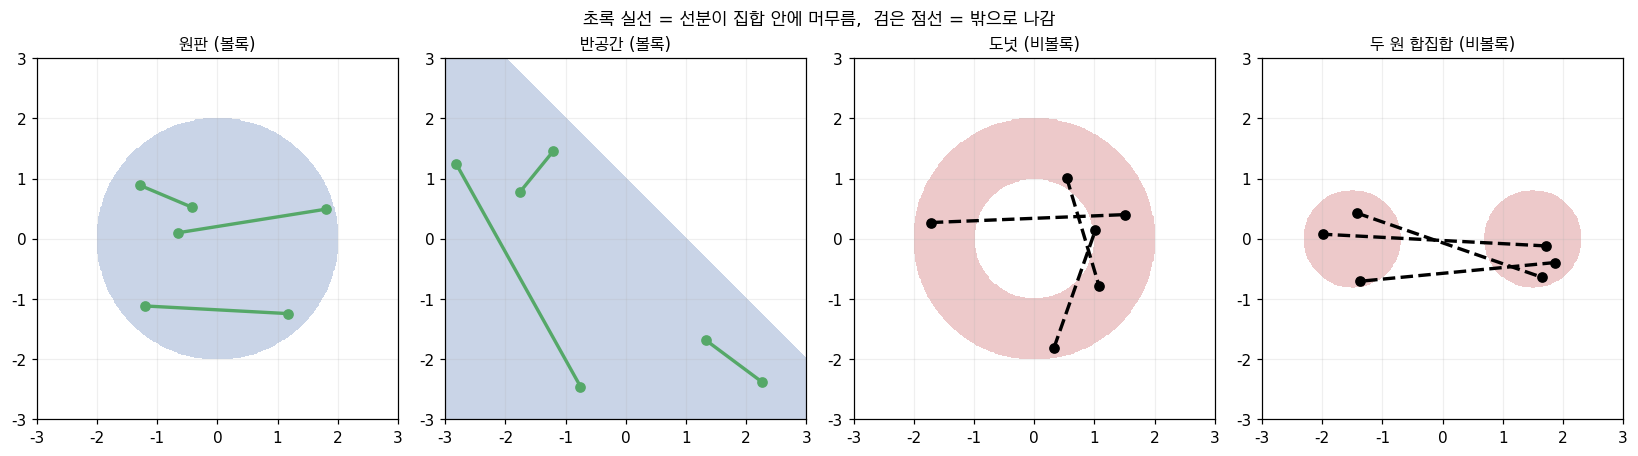

오른쪽 두 개에서 점선이 흰 영역(집합 밖)을 지나갑니다. 그래서 볼록이 아닙니다.


In [4]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
rng = np.random.default_rng(3)

configs = [
    ("원판 (볼록)", lambda p: np.linalg.norm(p) <= 2, True),
    ("반공간 (볼록)", lambda p: p[0] + p[1] <= 1, True),
    ("도넛 (비볼록)", lambda p: 1 <= np.linalg.norm(p) <= 2, False),
    ("두 원 합집합 (비볼록)", lambda p: (np.linalg.norm(p - np.array([-1.5, 0])) <= 0.8
                                        or np.linalg.norm(p - np.array([1.5, 0])) <= 0.8), False),
]

for ax, (title, memb, convex) in zip(axes, configs):
    gx, gy = np.meshgrid(np.linspace(-3, 3, 320), np.linspace(-3, 3, 320))
    mask = np.array([[memb(np.array([a, b])) for a, b in zip(rx, ry)]
                     for rx, ry in zip(gx, gy)])
    ax.contourf(gx, gy, mask.astype(float), levels=[0.5, 1.5],
                colors=["#4c72b0" if convex else "#c44e52"], alpha=0.3)

    # 선분 검사 예시 몇 개
    drawn = 0
    attempts = 0
    while drawn < 3 and attempts < 4000:
        attempts += 1
        p1, p2 = sample_in(memb, rng), sample_in(memb, rng)
        ts = np.linspace(0, 1, 40)[:, None]
        seg = ts * p1 + (1 - ts) * p2
        inside_all = all(memb(s) for s in seg)
        if convex and not inside_all:
            continue
        if (not convex) and inside_all and drawn < 2:
            continue
        color = "#55a868" if inside_all else "black"
        ax.plot(seg[:, 0], seg[:, 1], color=color, lw=2.2,
                ls="-" if inside_all else "--")
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], "o", color=color, ms=6)
        drawn += 1

    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect("equal")
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.2)

plt.suptitle("초록 실선 = 선분이 집합 안에 머무름,  검은 점선 = 밖으로 나감", fontsize=12)
plt.tight_layout()
plt.show()
print("오른쪽 두 개에서 점선이 흰 영역(집합 밖)을 지나갑니다. 그래서 볼록이 아닙니다.")

## 2️⃣ 볼록 함수 — 그래프 위의 두 점을 이으면

이제 함수입니다. 정의는 집합 버전과 거의 똑같이 생겼습니다.

$$f(tx + (1-t)y) \;\le\; t f(x) + (1-t) f(y), \qquad t \in [0,1]$$

**기하학적으로:** 그래프 위의 어떤 두 점을 이어도, **그 선분이 그래프 위(또는 그래프에 닿아)에 있습니다.**

왼쪽 변은 "두 점 사이 어딘가에서의 **함수값**"이고,
오른쪽 변은 "두 점을 이은 **직선의 높이**"입니다.
**직선이 항상 함수보다 위에 있으면 볼록**입니다.

| | 볼록 함수 | 비볼록 함수 |
| --- | --- | --- |
| **선분 검사** | 선분이 곡선 **위 또는 접함** | 어떤 구간에서 선분이 곡선 **아래로** 내려감 |
| **모양** | 위로 휜 골짜기 하나 | 봉우리와 골짜기가 여럿 |
| **최솟값** | 모든 지역 최솟값 = 전역 최솟값 | 서로 높이가 다른 지역 최솟값들 |

### 📐 대표적인 볼록 함수들

`x²` · `|x|` · `eˣ` · `max(0, x)` (ReLU) · `−log x` (x>0) · 모든 선형함수 `aᵀx + b`

마지막 항목이 재미있습니다. **선형함수는 볼록이면서 동시에 오목입니다.**
직선을 이으면 정확히 그 직선 자신이니까 부등식이 등호로 성립하거든요.

In [5]:
def check_convexity(f, dim, bounds=(-5, 5), samples=20000, tol=1e-9, seed=0):
    # 정의를 직접 검사합니다: f(tx+(1-t)y) ≤ t·f(x)+(1-t)·f(y)
    rng = np.random.default_rng(seed)
    violations = 0
    worst = 0.0
    for _ in range(samples):
        x = rng.uniform(*bounds, dim)
        y = rng.uniform(*bounds, dim)
        t = rng.random()
        lhs = f(t * x + (1 - t) * y)
        rhs = t * f(x) + (1 - t) * f(y)
        gap = lhs - rhs
        if gap > tol:
            violations += 1
            worst = max(worst, gap)
    return violations == 0, violations, worst

funcs_1d = [
    ("f(x) = x²",            lambda v: float(v[0] ** 2)),
    ("f(x) = |x|",           lambda v: float(abs(v[0]))),
    ("f(x) = eˣ",            lambda v: float(math.exp(min(v[0], 50)))),
    ("f(x) = max(0, x) ReLU", lambda v: float(max(0.0, v[0]))),
    ("f(x) = 3x + 1 (선형)",  lambda v: float(3 * v[0] + 1)),
    ("f(x) = x³",            lambda v: float(v[0] ** 3)),
    ("f(x) = sin(x)",        lambda v: float(math.sin(v[0]))),
    ("f(x) = x⁴ - 3x²",      lambda v: float(v[0] ** 4 - 3 * v[0] ** 2)),
]

print(f"{'함수':<26}{'볼록?':>10}{'위반 횟수':>12}{'최대 위반량':>16}")
print("-" * 66)
for name, f in funcs_1d:
    ok, v, worst = check_convexity(f, 1)
    print(f"{name:<26}{'✅' if ok else '❌':>8}{v:>12,}{worst:>16.4f}")

print("\n[선형함수는 볼록이면서 오목입니다 — 부등식이 등호로 성립]")
lin = lambda v: float(3 * v[0] + 1)
neg_lin = lambda v: -lin(v)
print(f"  f(x) = 3x+1  볼록? {check_convexity(lin, 1)[0]}")
print(f"  -f(x)        볼록? {check_convexity(neg_lin, 1)[0]}   <- 둘 다 볼록 = f는 오목이기도 합니다")

print("\n[2차원도 똑같이 됩니다]")
funcs_2d = [
    ("f(x,y) = x² + y²",    lambda v: float(v[0]**2 + v[1]**2)),
    ("f(x,y) = x·y",        lambda v: float(v[0] * v[1])),
    ("f(x,y) = max(x, y)",  lambda v: float(max(v[0], v[1]))),
    ("f(x,y) = x² - y²",    lambda v: float(v[0]**2 - v[1]**2)),
]
for name, f in funcs_2d:
    ok, v, _ = check_convexity(f, 2)
    print(f"  {name:<22}{'✅ 볼록' if ok else '❌ 비볼록':>12}  (위반 {v:,}회)")

함수                               볼록?       위반 횟수          최대 위반량
------------------------------------------------------------------
f(x) = x²                        ✅           0          0.0000
f(x) = |x|                       ✅           0          0.0000
f(x) = eˣ                        ✅           0          0.0000
f(x) = max(0, x) ReLU            ✅           0          0.0000
f(x) = 3x + 1 (선형)               ✅           0          0.0000
f(x) = x³                        ❌       9,898         60.1427
f(x) = sin(x)                    ❌       9,986          1.9958
f(x) = x⁴ - 3x²                  ❌       1,477          2.1761

[선형함수는 볼록이면서 오목입니다 — 부등식이 등호로 성립]
  f(x) = 3x+1  볼록? True
  -f(x)        볼록? True   <- 둘 다 볼록 = f는 오목이기도 합니다

[2차원도 똑같이 됩니다]
  f(x,y) = x² + y²              ✅ 볼록  (위반 0회)
  f(x,y) = x·y                 ❌ 비볼록  (위반 10,022회)
  f(x,y) = max(x, y)            ✅ 볼록  (위반 0회)
  f(x,y) = x² - y²             ❌ 비볼록  (위반 9,950회)


### 🖼️ 그림 2 — 선분이 곡선 위에 있는가

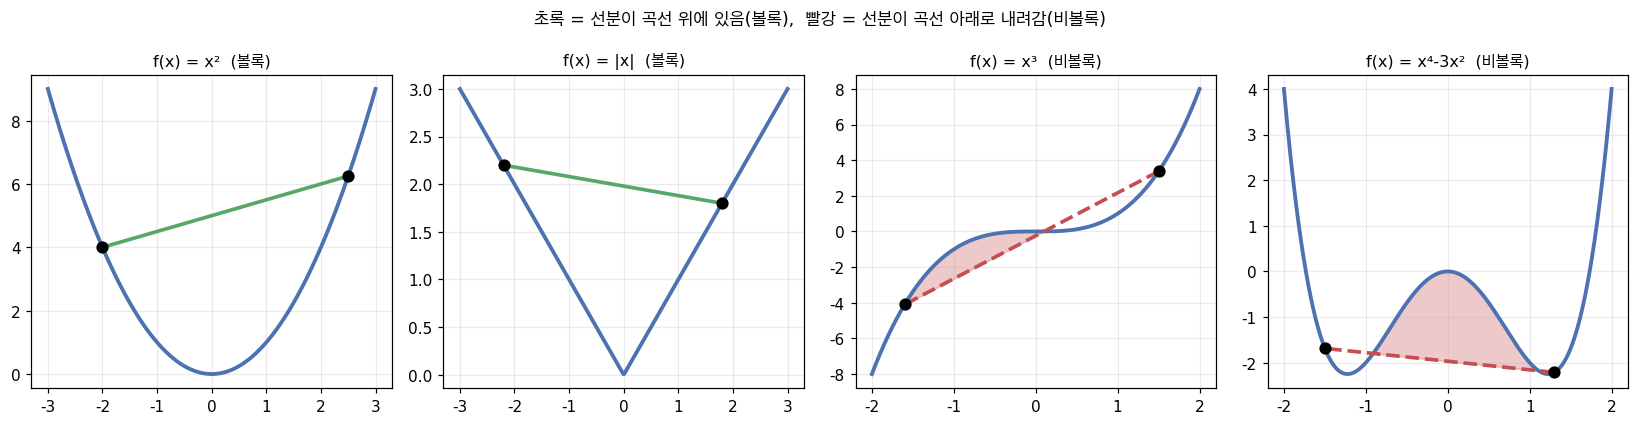

세 번째·네 번째에서 빨간 영역이 '정의를 위반한 구간'입니다.
두 점을 잇는 선이 곡선보다 아래로 내려가면 그 함수는 볼록이 아닙니다.


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.9))
demos = [
    ("f(x) = x²  (볼록)", lambda x: x ** 2, (-3, 3), True),
    ("f(x) = |x|  (볼록)", lambda x: np.abs(x), (-3, 3), True),
    ("f(x) = x³  (비볼록)", lambda x: x ** 3, (-2, 2), False),
    ("f(x) = x⁴-3x²  (비볼록)", lambda x: x ** 4 - 3 * x ** 2, (-2, 2), False),
]
picks = [(-2.0, 2.5), (-2.2, 1.8), (-1.6, 1.5), (-1.5, 1.3)]

for ax, (title, f, rng_x, convex), (a, b) in zip(axes, demos, picks):
    xs = np.linspace(*rng_x, 400)
    ax.plot(xs, f(xs), lw=2.5, color="#4c72b0")
    ts = np.linspace(0, 1, 100)
    seg_x = ts * a + (1 - ts) * b
    seg_y = ts * f(a) + (1 - ts) * f(b)
    below = seg_y < f(seg_x) - 1e-12
    ax.plot(seg_x, seg_y, lw=2.4, color="#55a868" if not below.any() else "#c44e52",
            ls="-" if not below.any() else "--")
    if below.any():
        ax.fill_between(seg_x[below], seg_y[below], f(seg_x[below]),
                        color="#c44e52", alpha=0.3)
    ax.plot([a, b], [f(a), f(b)], "o", ms=7, color="black", zorder=5)
    ax.set_title(title, fontsize=10.5)
    ax.grid(alpha=0.25)
plt.suptitle("초록 = 선분이 곡선 위에 있음(볼록),  빨강 = 선분이 곡선 아래로 내려감(비볼록)",
             fontsize=11.5)
plt.tight_layout()
plt.show()
print("세 번째·네 번째에서 빨간 영역이 '정의를 위반한 구간'입니다.")
print("두 점을 잇는 선이 곡선보다 아래로 내려가면 그 함수는 볼록이 아닙니다.")

## 3️⃣ 볼록성 판정 3종 세트

실무에서 쓰는 순서대로 정리하면 이렇습니다.

### 📐 방법 1 — 2계 도함수 (1차원)

$$f''(x) \ge 0 \;\; \forall x \quad\Longrightarrow\quad f\text{는 볼록}$$

- `f(x) = x²` → `f'' = 2 ≥ 0` → **볼록**
- `f(x) = x³` → `f'' = 6x` → `x < 0`에서 음수 → **비볼록**
- `f(x) = eˣ` → `f'' = eˣ > 0` → **볼록**

가장 간단하지만 1차원에서만 씁니다.

### 📐 방법 2 — 헤시안 (다변수)

헤시안 `H(x)`가 **모든 `x`에서 양반정부호**(모든 고유값 ≥ 0)면 볼록입니다.

이게 "2계 도함수 ≥ 0"의 다차원 버전입니다.
**모든 방향으로 위로 휘어 있다**는 뜻이에요.

> 💡 여기서 지난 노트북(선형 시스템)과 만납니다. 양정부호 행렬은 **촐레스키 분해가 성공**하는 행렬이었죠.
> 그래서 촐레스키 분해를 시도해 보는 것만으로 볼록성 판정이 됩니다.

### 📐 방법 3 — 정의 직접 검사

$$f(tx + (1-t)y) \le tf(x) + (1-t)f(y)$$

도함수를 구하기 어려운 함수에 유용합니다. 2절에서 쓴 방법이고요.

> ⚠️ 다만 **무작위 검사는 반례를 못 찾았을 뿐, 볼록성을 증명하지는 못합니다.**
> "위반을 발견하지 못했다"와 "위반이 없다"는 다릅니다. (6주차 가설검정의 그 논리와 같습니다.)

In [7]:
def numeric_hessian(f, x, h=1e-4):
    x = np.asarray(x, dtype=float)
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            xpp, xpm, xmp, xmm = x.copy(), x.copy(), x.copy(), x.copy()
            xpp[i] += h; xpp[j] += h
            xpm[i] += h; xpm[j] -= h
            xmp[i] -= h; xmp[j] += h
            xmm[i] -= h; xmm[j] -= h
            H[i, j] = (f(xpp) - f(xpm) - f(xmp) + f(xmm)) / (4 * h * h)
    return (H + H.T) / 2                      # 수치 오차로 깨진 대칭성을 복구

def hessian_verdict(f, dim, bounds=(-3, 3), samples=400, seed=0):
    # 여러 점에서 헤시안 고유값을 확인합니다
    rng = np.random.default_rng(seed)
    min_eig = float("inf")
    for _ in range(samples):
        x = rng.uniform(*bounds, dim)
        eig = np.linalg.eigvalsh(numeric_hessian(f, x))
        min_eig = min(min_eig, eig.min())
    return min_eig

print("[방법 2] 헤시안의 최소 고유값 — 0 이상이면 볼록입니다\n")
print(f"{'함수':<26}{'관측된 최소 고유값':>22}{'판정':>12}")
print("-" * 62)
tests = [
    ("f(x,y) = x² + y²",        lambda v: v[0]**2 + v[1]**2),
    ("f(x,y) = x² + 3xy + y²",  lambda v: v[0]**2 + 3*v[0]*v[1] + v[1]**2),
    ("f(x,y) = x² + xy + y²",   lambda v: v[0]**2 + v[0]*v[1] + v[1]**2),
    ("f(x,y) = x·y",            lambda v: v[0] * v[1]),
    ("f(x,y) = eˣ + y²",        lambda v: math.exp(min(v[0], 30)) + v[1]**2),
]
for name, f in tests:
    m = hessian_verdict(f, 2)
    print(f"{name:<26}{m:>22.4f}{'✅ 볼록' if m >= -1e-6 else '❌ 비볼록':>12}")

print("\n[손으로 푼 예시와 대조] f(x,y) = x² + 3xy + y²")
print("  ∂f/∂x = 2x + 3y,  ∂f/∂y = 3x + 2y")
print("  H = [[2, 3], [3, 2]]  (상수 행렬)")
H_exact = np.array([[2.0, 3.0], [3.0, 2.0]])
print(f"  수치 헤시안: \n{np.round(numeric_hessian(tests[1][1], [1.0, 1.0]), 4)}")
print(f"  고유값: {np.linalg.eigvalsh(H_exact)}  <- -1이 있으므로 비볼록 (안장 방향 존재)")

print("\n[💡 촐레스키로도 판정됩니다 — 지난 노트북과의 연결]")
for name, H in [("[[2,3],[3,2]]  (비볼록)", H_exact), ("[[2,1],[1,2]]  (볼록)", np.array([[2.0,1],[1,2]]))]:
    try:
        np.linalg.cholesky(H)
        print(f"  {name}: 촐레스키 성공 -> 양정부호 -> 볼록")
    except np.linalg.LinAlgError:
        print(f"  {name}: 촐레스키 실패 -> 양정부호 아님 -> 비볼록")

[방법 2] 헤시안의 최소 고유값 — 0 이상이면 볼록입니다

함수                                    관측된 최소 고유값          판정
--------------------------------------------------------------
f(x,y) = x² + y²                          2.0000        ✅ 볼록
f(x,y) = x² + 3xy + y²                   -1.0000       ❌ 비볼록
f(x,y) = x² + xy + y²                     1.0000        ✅ 볼록
f(x,y) = x·y                             -1.0000       ❌ 비볼록
f(x,y) = eˣ + y²                          0.0517        ✅ 볼록

[손으로 푼 예시와 대조] f(x,y) = x² + 3xy + y²
  ∂f/∂x = 2x + 3y,  ∂f/∂y = 3x + 2y
  H = [[2, 3], [3, 2]]  (상수 행렬)
  수치 헤시안: 
[[2. 3.]
 [3. 2.]]
  고유값: [-1.  5.]  <- -1이 있으므로 비볼록 (안장 방향 존재)

[💡 촐레스키로도 판정됩니다 — 지난 노트북과의 연결]
  [[2,3],[3,2]]  (비볼록): 촐레스키 실패 -> 양정부호 아님 -> 비볼록
  [[2,1],[1,2]]  (볼록): 촐레스키 성공 -> 양정부호 -> 볼록


## 4️⃣ 🔑 왜 볼록성이 중요한가 — 중심 정리

볼록 최적화의 핵심 정리는 딱 한 줄입니다.

> ### **볼록 함수에서는 모든 지역 최솟값이 전역 최솟값이다.**

이 문장이 실무에서 뜻하는 바:

- 경사하강법이 **함정에 빠질 수 없습니다.** 어떤 내리막 경로든 같은 답에 도달합니다
- **무작위 재시작이 필요 없습니다**
- **정교한 학습률 스케줄이 필요 없습니다**
- **수렴 증명이 가능합니다** (수렴 속도까지 함수의 성질로 계산됩니다)
- **해가 유일합니다** (평평한 영역을 제외하면)

### 📐 왜 그런가 — 증명 스케치

`x*`가 지역 최솟값인데 전역 최솟값이 아니라고 해 봅시다.
그러면 `f(y) < f(x*)`인 점 `y`가 어딘가 있겠죠.

볼록성에 의해, `x*`와 `y` 사이의 모든 점에서:

$$f(tx^* + (1-t)y) \le tf(x^*) + (1-t)f(y) < f(x^*)$$

즉 **`x*` 바로 옆에도 `x*`보다 낮은 점이 있습니다.** `x*`가 지역 최솟값이라는 가정에 모순이죠.
따라서 그런 `y`는 존재할 수 없습니다. ∎

### 🏭 ML 문제별 볼록성

| 문제 | 볼록? | 이유 |
| --- | --- | --- |
| 선형회귀 (MSE) | ✅ | 손실이 가중치에 대해 이차식 |
| 로지스틱회귀 | ✅ | 로그손실이 가중치에 대해 볼록 |
| SVM (힌지 손실) | ✅ | 선형함수들의 최댓값 |
| LASSO (L1) | ✅ | 볼록 함수들의 합은 볼록 |
| 릿지회귀 (L2) | ✅ | 이차 + 이차 = 볼록 |
| **신경망 (어떤 손실이든)** | ❌ | **비선형 활성화가 볼록성을 깨뜨림** |
| k-평균 군집화 | ❌ | 할당 단계가 이산적 |
| 행렬 분해 | ❌ | 미지수끼리의 곱 |

**선형 모델 + 볼록 손실 = 볼록**입니다.
**은닉층과 비선형 활성화를 넣는 순간 볼록성이 깨집니다.**

In [8]:
# '모든 지역 최솟값 = 전역 최솟값'을 실험으로 확인합니다
def multi_start_gd(grad, dim, n_starts=300, lr=0.02, steps=3000, bounds=(-5, 5), seed=0):
    rng = np.random.default_rng(seed)
    finals = []
    for _ in range(n_starts):
        x = rng.uniform(*bounds, dim)
        for _ in range(steps):
            g = np.asarray(grad(x))
            if np.linalg.norm(g) < 1e-12:
                break
            x = x - lr * g
        finals.append(x)
    return np.array(finals)

# 볼록: f = x² + y² + 0.5xy
convex_grad2 = lambda v: np.array([2*v[0] + 0.5*v[1], 2*v[1] + 0.5*v[0]])
convex_val = lambda v: v[0]**2 + v[1]**2 + 0.5*v[0]*v[1]

# 비볼록: 여러 골짜기를 가진 함수
def rastrigin_like(v):
    return (v[0]**2 + v[1]**2) / 8 + 2*math.cos(2*v[0]) + 2*math.cos(2*v[1])
def rastrigin_grad(v):
    return np.array([v[0]/4 - 4*math.sin(2*v[0]), v[1]/4 - 4*math.sin(2*v[1])])

for tag, grad, val in [("볼록 함수", convex_grad2, convex_val),
                       ("비볼록 함수", rastrigin_grad, rastrigin_like)]:
    finals = multi_start_gd(grad, 2, n_starts=300, lr=0.02, steps=3000, seed=1)
    vals = np.array([val(p) for p in finals])
    # 도착한 서로 다른 지점의 개수를 셉니다 (반올림해서 군집화)
    uniq = {tuple(np.round(p, 2)) for p in finals}
    print(f"[{tag}] 무작위 시작점 300개")
    print(f"  도착한 서로 다른 지점 : {len(uniq)}곳")
    print(f"  도착 지점의 손실 범위 : {vals.min():.6f} ~ {vals.max():.6f}")
    print(f"  손실의 표준편차       : {vals.std():.6f}")
    print()

print("=> 볼록 함수는 300개 시작점이 전부 한 점으로 모입니다. 손실 표준편차가 0입니다.")
print("   비볼록 함수는 여러 곳으로 흩어지고, 도착한 손실값도 제각각입니다.")
print("   이게 '재시작이 필요한가'의 실질적 의미입니다.")

[볼록 함수] 무작위 시작점 300개
  도착한 서로 다른 지점 : 1곳
  도착 지점의 손실 범위 : 0.000000 ~ 0.000000
  손실의 표준편차       : 0.000000

[비볼록 함수] 무작위 시작점 300개
  도착한 서로 다른 지점 : 16곳
  도착 지점의 손실 범위 : -3.401856 ~ 1.382285
  손실의 표준편차       : 1.648891

=> 볼록 함수는 300개 시작점이 전부 한 점으로 모입니다. 손실 표준편차가 0입니다.
   비볼록 함수는 여러 곳으로 흩어지고, 도착한 손실값도 제각각입니다.
   이게 '재시작이 필요한가'의 실질적 의미입니다.


### 🖼️ 그림 3 — 골짜기 하나 vs 골짜기 여럿

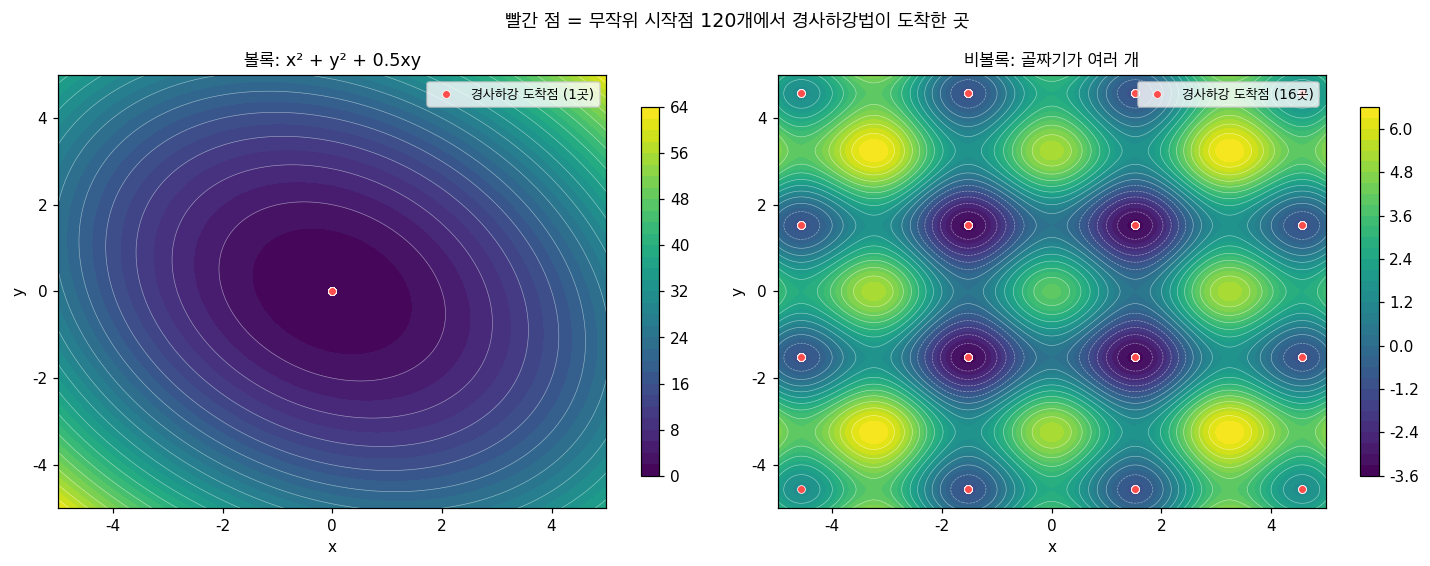

왼쪽: 빨간 점이 한 곳에 완전히 겹쳐 있습니다. 어디서 출발해도 같은 답입니다.
오른쪽: 빨간 점이 격자 모양으로 흩어져 있습니다. 각각이 서로 다른 지역 최솟값이에요.

신경망은 오른쪽이지만 차원이 백만 단위입니다. 11절에서 그런데도 왜 작동하는지 다룹니다.


In [9]:
fig = plt.figure(figsize=(13.5, 5.2))
gx, gy = np.meshgrid(np.linspace(-5, 5, 220), np.linspace(-5, 5, 220))

for idx, (title, valfn, gradfn) in enumerate([
        ("볼록: x² + y² + 0.5xy", convex_val, convex_grad2),
        ("비볼록: 골짜기가 여러 개", rastrigin_like, rastrigin_grad)]):
    Z = np.array([[valfn(np.array([a, b])) for a, b in zip(rx, ry)]
                  for rx, ry in zip(gx, gy)])
    ax = fig.add_subplot(1, 2, idx + 1)
    cf = ax.contourf(gx, gy, Z, levels=35, cmap="viridis")
    ax.contour(gx, gy, Z, levels=18, colors="white", linewidths=0.4, alpha=0.5)

    finals = multi_start_gd(gradfn, 2, n_starts=120, lr=0.02, steps=3000, seed=1)
    ax.scatter(finals[:, 0], finals[:, 1], s=26, color="#ff4d4d",
               edgecolor="white", linewidth=0.5, zorder=5,
               label=f"경사하강 도착점 ({len({tuple(np.round(p,2)) for p in finals})}곳)")
    ax.set_title(title, fontsize=11.5)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend(fontsize=9, loc="upper right")
    plt.colorbar(cf, ax=ax, shrink=0.85)

plt.suptitle("빨간 점 = 무작위 시작점 120개에서 경사하강법이 도착한 곳", fontsize=12.5)
plt.tight_layout()
plt.show()

print("왼쪽: 빨간 점이 한 곳에 완전히 겹쳐 있습니다. 어디서 출발해도 같은 답입니다.")
print("오른쪽: 빨간 점이 격자 모양으로 흩어져 있습니다. 각각이 서로 다른 지역 최솟값이에요.")
print("\n신경망은 오른쪽이지만 차원이 백만 단위입니다. 11절에서 그런데도 왜 작동하는지 다룹니다.")

## 5️⃣ 헤시안 — 곡률을 담은 행렬

`f: ℝⁿ → ℝ`의 헤시안 `H`는 **2계 편도함수를 모은 `n × n` 행렬**입니다.

$$H_{ij} = \frac{\partial^2 f}{\partial x_i \partial x_j}$$

`f(x,y) = x² + 3xy + y²` 를 예로 들면:

```
∂f/∂x = 2x + 3y       ∂²f/∂x²  = 2      ∂²f/∂x∂y = 3
∂f/∂y = 3x + 2y       ∂²f/∂y∂x = 3      ∂²f/∂y²  = 2

H = | 2  3 |
    | 3  2 |
```

### 🔑 고유값이 곡률을 알려줍니다

| 고유값 | 그 지점의 모양 |
| --- | --- |
| 전부 양수 | 모든 방향으로 위로 휨 → **지역 최솟값** |
| 전부 음수 | 모든 방향으로 아래로 휨 → **지역 최댓값** |
| 부호가 섞임 | 어떤 방향은 위로, 어떤 방향은 아래로 → **안장점** |
| 0이 있음 | 그 방향으로 평평함 (퇴화) |

그리고 **고유벡터는 그 곡률의 방향**입니다.
고유값이 크면 그 방향으로 가파르고, 작으면 완만합니다.

> 🔗 여기서 지난 노트북의 **조건수**가 다시 나옵니다.
> `κ = λ_max / λ_min`이 크면 골짜기가 **길쭉하게 찌그러져** 있다는 뜻이고,
> 경사하강법은 그런 골짜기에서 지그재그로 헤맵니다. 6절에서 직접 봅니다.

In [10]:
def numeric_gradient(f, x, h=1e-6):
    x = np.asarray(x, dtype=float)
    out = np.zeros(len(x))
    for i in range(len(x)):
        xp, xm = x.copy(), x.copy()
        xp[i] += h; xm[i] -= h
        out[i] = (f(xp) - f(xm)) / (2 * h)
    return out

def analyze_point(f, x, name=""):
    H = numeric_hessian(f, x)
    eig, vec = np.linalg.eigh(H)
    if (eig > 1e-6).all():
        kind = "지역 최솟값 (모든 방향 위로 휨)"
    elif (eig < -1e-6).all():
        kind = "지역 최댓값 (모든 방향 아래로 휨)"
    elif (eig > 1e-6).any() and (eig < -1e-6).any():
        kind = "안장점 (방향에 따라 다름)"
    else:
        kind = "퇴화 (평평한 방향 있음)"
    gnorm = np.linalg.norm(numeric_gradient(f, x))
    crit = "임계점 (∇f = 0)" if gnorm < 1e-4 else f"임계점 아님 (‖∇f‖ = {gnorm:.2f})"
    print(f"  {name} at {np.round(x, 3)}")
    print(f"    H =\n{np.array2string(np.round(H, 4), prefix='        ')}")
    print(f"    고유값: {np.round(eig, 4)}")
    print(f"    곡률 판정: {kind}")
    print(f"    임계점 여부: {crit}")
    if (eig > 1e-9).all():
        print(f"    조건수 κ = {eig.max()/eig.min():.2f}")
    return eig

print("[여러 지점에서 곡률을 읽어 봅니다]\n")
bowl = lambda v: v[0]**2 + v[1]**2
saddle = lambda v: v[0]**2 - v[1]**2
elongated = lambda v: 50*v[0]**2 + v[1]**2

analyze_point(bowl, [0.0, 0.0], "f = x² + y²  (그릇)")
print()
analyze_point(saddle, [0.0, 0.0], "f = x² - y²  (안장)")
print()
analyze_point(elongated, [0.0, 0.0], "f = 50x² + y²  (길쭉한 골짜기)")

print("\n[로젠브록 함수 — 최솟값과 그 밖에서 곡률이 어떻게 다른가]  (연습 5)")
rosen = lambda v: (1 - v[0])**2 + 100 * (v[1] - v[0]**2)**2
print()
e_min = analyze_point(rosen, [1.0, 1.0], "전역 최솟값 (1,1)")
print()
e_far = analyze_point(rosen, [-1.0, 1.0], "최솟값에서 먼 (-1,1)")
print()
e_sad = analyze_point(rosen, [0.0, 1.0], "골짜기 능선 위 (0,1)")

print(f"\n  💡 세 지점을 비교해서 읽는 법:")
print(f"     (1,1)  : 기울기가 0이고 고유값이 전부 양수 -> 진짜 최솟값입니다.")
print(f"              다만 조건수가 {e_min.max()/e_min.min():.0f}으로 극심합니다. 그래서 '바나나 골짜기'라 불리고")
print(f"              경사하강법이 악명 높게 고전합니다 (6절의 지그재그가 여기서 최악으로 나타납니다).")
print(f"     (-1,1) : 고유값이 (1,1)과 '완전히 같습니다'. 놀랍지만 사실입니다.")
print(f"              2×2 대칭행렬의 고유값은 비대각 원소의 '제곱'에만 의존하는데,")
print(f"              로젠브록은 이 두 점에서 비대각 원소의 부호만 다르기 때문입니다.")
print(f"              그런데 기울기가 0이 아니므로 임계점조차 아닙니다.")
print(f"              => 헤시안이 양정부호라고 최솟값인 게 아닙니다. 기울기가 0이어야 최솟값입니다.")
print(f"     (0,1)  : 여기서는 고유값에 음수가 섞입니다 -> 이 지점은 안장 방향을 가집니다.")

[여러 지점에서 곡률을 읽어 봅니다]

  f = x² + y²  (그릇) at [0. 0.]
    H =
[[2. 0.]
         [0. 2.]]
    고유값: [2. 2.]
    곡률 판정: 지역 최솟값 (모든 방향 위로 휨)
    임계점 여부: 임계점 (∇f = 0)
    조건수 κ = 1.00

  f = x² - y²  (안장) at [0. 0.]
    H =
[[ 2.  0.]
         [ 0. -2.]]
    고유값: [-2.  2.]
    곡률 판정: 안장점 (방향에 따라 다름)
    임계점 여부: 임계점 (∇f = 0)

  f = 50x² + y²  (길쭉한 골짜기) at [0. 0.]
    H =
[[100.   0.]
         [  0.   2.]]
    고유값: [  2. 100.]
    곡률 판정: 지역 최솟값 (모든 방향 위로 휨)
    임계점 여부: 임계점 (∇f = 0)
    조건수 κ = 50.00

[로젠브록 함수 — 최솟값과 그 밖에서 곡률이 어떻게 다른가]  (연습 5)

  전역 최솟값 (1,1) at [1. 1.]
    H =
[[ 802. -400.]
         [-400.  200.]]
    고유값: [   0.3994 1001.6006]
    곡률 판정: 지역 최솟값 (모든 방향 위로 휨)
    임계점 여부: 임계점 (∇f = 0)
    조건수 κ = 2508.00

  최솟값에서 먼 (-1,1) at [-1.  1.]
    H =
[[802. 400.]
         [400. 200.]]
    고유값: [   0.3994 1001.6006]
    곡률 판정: 지역 최솟값 (모든 방향 위로 휨)
    임계점 여부: 임계점 아님 (‖∇f‖ = 4.00)
    조건수 κ = 2508.00

  골짜기 능선 위 (0,1) at [0. 1.]
    H =
[[-398.    0.]
         [   0.  200.]]
    고유값: [-39

## 6️⃣ 🔨 뉴턴법 — 곡률을 알면 한 번에 갑니다

경사하강법은 **1차 정보(기울기)** 만 씁니다. 뉴턴법은 **2차 정보(헤시안)** 까지 씁니다.

$$\text{경사하강: } x \leftarrow x - \eta\,\nabla f \qquad
\text{뉴턴법: } x \leftarrow x - H^{-1}\nabla f$$

**스칼라 학습률 `η`가 역헤시안 `H⁻¹`로 바뀌었습니다.**
이게 무슨 뜻이냐면, **방향마다 다른 보폭**을 자동으로 쓴다는 겁니다.
가파른 방향은 조금, 완만한 방향은 많이 움직입니다.

### 📐 발상: 지금 위치에서 이차함수로 근사하고, 그 이차함수의 최솟값으로 점프

$$f(x + \Delta) \approx f(x) + \nabla f^\top\Delta + \tfrac12 \Delta^\top H \Delta$$

이 근사식을 `Δ`에 대해 미분해서 0으로 두면 정확히 `Δ = −H⁻¹∇f`가 나옵니다.

**그래서 함수가 진짜 이차식이면 뉴턴법은 딱 1스텝에 정답에 도달합니다.**

### ⚖️ 장단점

| | 장점 | 단점 |
| --- | --- | --- |
| 수렴 | **2차 수렴** (오차가 매 스텝 제곱됨) | 시작점이 멀면 발산할 수 있음 |
| 튜닝 | **학습률 없음** | — |
| 스케일 | **파라미터 스케일에 무관** | — |
| 비용 | — | 헤시안 저장 **O(n²)**, 역변환 **O(n³)** |

마지막 줄이 결정적입니다. 파라미터가 100만 개인 신경망이면
헤시안이 **10¹²개 원소**이고 역변환에 **10¹⁸번 연산**이 듭니다. **딥러닝에는 못 씁니다.**

> 💡 실전에서는 `H⁻¹`를 직접 구하지 않고 **선형 시스템 `Hd = −∇f`를 푼다**는 점도 중요합니다.
> 지난 노트북에서 배운 그대로예요. `H`가 양정부호면 **촐레스키**로 풀 수 있습니다.

In [11]:
def gradient_descent(grad, x0, lr, steps=2000, tol=1e-14):
    x = np.array(x0, dtype=float)
    hist = [x.copy()]
    for _ in range(steps):
        g = np.asarray(grad(x), dtype=float)
        if g @ g < tol:
            break
        x = x - lr * g
        hist.append(x.copy())
    return np.array(hist)

def newtons_method(grad, hess, x0, steps=60, tol=1e-14):
    x = np.array(x0, dtype=float)
    hist = [x.copy()]
    for _ in range(steps):
        g = np.asarray(grad(x), dtype=float)
        H = np.asarray(hess(x), dtype=float)
        if g @ g < tol:
            break
        try:
            # H⁻¹를 만들지 않고 선형 시스템을 풉니다 (지난 노트북의 교훈)
            step = np.linalg.solve(H, g)
        except np.linalg.LinAlgError:
            break
        x = x - step
        hist.append(x.copy())
    return np.array(hist)

# f(x,y) = 5x² + y²  — 이차식이므로 뉴턴법은 1스텝이어야 합니다
q_val = lambda v: 5*v[0]**2 + v[1]**2
q_grad = lambda v: np.array([10*v[0], 2*v[1]])
q_hess = lambda v: np.array([[10.0, 0.0], [0.0, 2.0]])

x0 = [10.0, 10.0]
h_newton = newtons_method(q_grad, q_hess, x0)
h_gd = gradient_descent(q_grad, x0, lr=0.09, steps=2000)

print("f(x,y) = 5x² + y²,  시작점 (10, 10),  목표 손실 < 1e-10\n")
def steps_to(hist, valfn, target=1e-10):
    for k, p in enumerate(hist):
        if valfn(p) < target:
            return k
    return None

print(f"  뉴턴법     : {steps_to(h_newton, q_val)}스텝   최종 {np.round(h_newton[-1], 12)}")
print(f"  경사하강법 : {steps_to(h_gd, q_val)}스텝   최종 {np.round(h_gd[-1], 12)}")
print(f"\n  헤시안 고유값 {np.linalg.eigvalsh(q_hess(x0))},  조건수 κ = 5")

print("\n[조건수를 키우면 경사하강법만 무너집니다]")
print(f"{'조건수 κ':>12}{'뉴턴법 스텝':>16}{'경사하강 스텝':>18}")
print("-" * 48)
for kappa in [1, 5, 50, 500, 5000]:
    a = float(kappa)
    val = lambda v, a=a: a*v[0]**2 + v[1]**2
    gr = lambda v, a=a: np.array([2*a*v[0], 2*v[1]])
    he = lambda v, a=a: np.array([[2*a, 0.0], [0.0, 2.0]])
    hn = newtons_method(gr, he, [10.0, 10.0])
    lr_safe = 1.0 / (2 * a) * 0.9              # 발산하지 않는 최대 학습률 근처
    hg = gradient_descent(gr, [10.0, 10.0], lr=lr_safe, steps=200000)
    sn, sg = steps_to(hn, val), steps_to(hg, val)
    print(f"{kappa:>12}{str(sn):>16}{str(sg):>18}")

print("\n=> 뉴턴법은 조건수와 무관하게 1스텝입니다 (이차식이니까요).")
print("   경사하강법은 조건수에 비례해 스텝이 늘어납니다. 이게 '스케일 불변'의 의미입니다.")

f(x,y) = 5x² + y²,  시작점 (10, 10),  목표 손실 < 1e-10

  뉴턴법     : 1스텝   최종 [0. 0.]
  경사하강법 : 70스텝   최종 [0. 0.]

  헤시안 고유값 [ 2. 10.],  조건수 κ = 5

[조건수를 키우면 경사하강법만 무너집니다]
       조건수 κ          뉴턴법 스텝           경사하강 스텝
------------------------------------------------
           1               1                 7
           5               1                70
          50               1               761
         500               1              7669
        5000               1             76746

=> 뉴턴법은 조건수와 무관하게 1스텝입니다 (이차식이니까요).
   경사하강법은 조건수에 비례해 스텝이 늘어납니다. 이게 '스케일 불변'의 의미입니다.


### 🖼️ 그림 4 — 지그재그 vs 직행

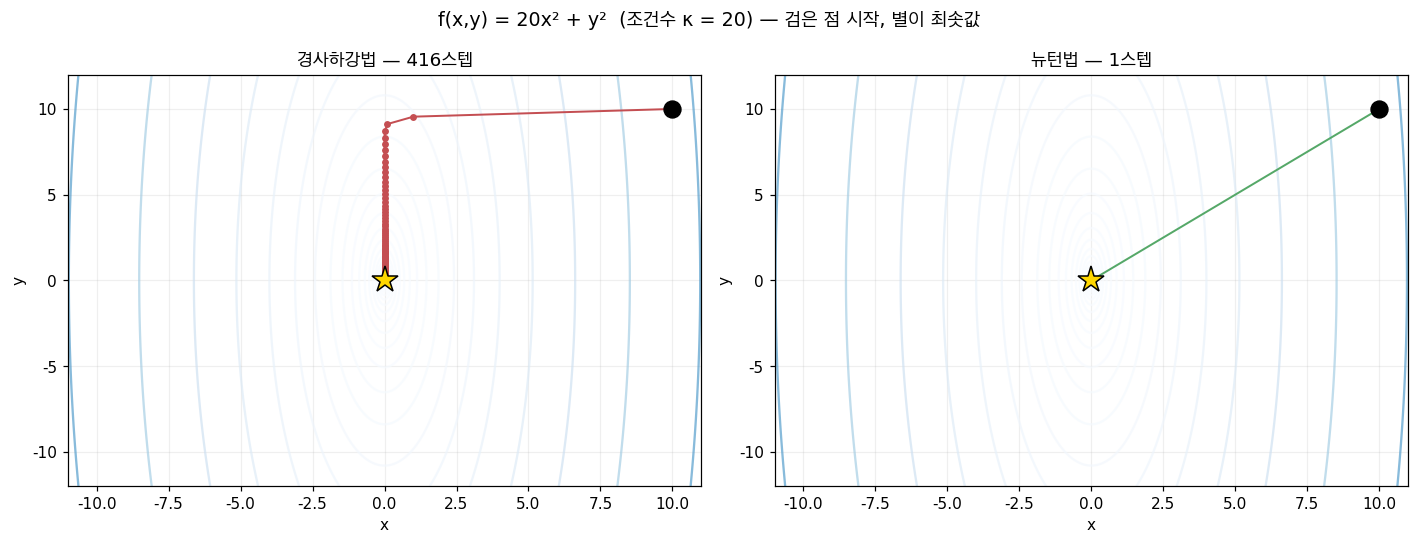

왼쪽: 경사하강법은 좁은 축(x) 방향으로 튕기면서 넓은 축(y)을 따라 천천히 내려갑니다.
      기울기는 '가장 가파른 방향'을 가리키지만, 그게 '최솟값 방향'은 아니기 때문입니다.
오른쪽: 뉴턴법은 헤시안으로 축의 스케일을 보정해 한 번에 정확히 도착합니다.

[2차 수렴이란 무엇인가 — 비이차 함수에서 확인]
  수렴점: [-0.37492 -0.06249]
    스텝          ‖x - x*‖             이전 오차의 제곱
------------------------------------------------
     0        3.1455e+00                     —
     1        1.1923e+00             9.894e+00
     2        2.6952e-01             1.422e+00
     3        1.0791e-02             7.264e-02
     4        1.5725e-05             1.164e-04

  => 오차가 '이전 오차의 제곱' 수준으로 줄어듭니다. 유효숫자가 매 스텝 2배가 되는 거죠.
     그래서 뉴턴법은 몇 스텝 만에 기계 정밀도 한계에 도달합니다.


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

a = 20.0
val = lambda v: a*v[0]**2 + v[1]**2
gr = lambda v: np.array([2*a*v[0], 2*v[1]])
he = lambda v: np.array([[2*a, 0.0], [0.0, 2.0]])

gx, gy = np.meshgrid(np.linspace(-11, 11, 300), np.linspace(-12, 12, 300))
Z = a * gx**2 + gy**2

h_n = newtons_method(gr, he, [10.0, 10.0])
h_g = gradient_descent(gr, [10.0, 10.0], lr=0.9/(2*a), steps=3000)

for ax, hist, title, color in [
    (ax1, h_g, f"경사하강법 — {len(h_g)-1}스텝", "#c44e52"),
    (ax2, h_n, f"뉴턴법 — {len(h_n)-1}스텝", "#55a868"),
]:
    ax.contour(gx, gy, Z, levels=np.logspace(-1, 3.6, 22), cmap="Blues", alpha=0.65)
    show = hist[:min(len(hist), 400)]
    ax.plot(show[:, 0], show[:, 1], "-o", ms=3.5, lw=1.3, color=color)
    ax.plot(*hist[0], "o", ms=11, color="black", zorder=6)
    ax.plot(0, 0, "*", ms=18, color="gold", markeredgecolor="black", zorder=6)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_xlim(-11, 11); ax.set_ylim(-12, 12)
    ax.grid(alpha=0.2)

plt.suptitle(f"f(x,y) = {a:g}x² + y²  (조건수 κ = {a:g}) — 검은 점 시작, 별이 최솟값", fontsize=12.5)
plt.tight_layout()
plt.show()

print("왼쪽: 경사하강법은 좁은 축(x) 방향으로 튕기면서 넓은 축(y)을 따라 천천히 내려갑니다.")
print("      기울기는 '가장 가파른 방향'을 가리키지만, 그게 '최솟값 방향'은 아니기 때문입니다.")
print("오른쪽: 뉴턴법은 헤시안으로 축의 스케일을 보정해 한 번에 정확히 도착합니다.")

# 2차 수렴 확인 (비이차 함수에서)
print("\n[2차 수렴이란 무엇인가 — 비이차 함수에서 확인]")
f_nq = lambda v: math.exp(v[0]) + v[0]**2 + 3*v[1]**2 - v[0]*v[1]
g_nq = lambda v: np.array([math.exp(v[0]) + 2*v[0] - v[1], 6*v[1] - v[0]])
h_nq = lambda v: np.array([[math.exp(v[0]) + 2, -1.0], [-1.0, 6.0]])
hist = newtons_method(g_nq, h_nq, [2.0, 2.0], steps=12)
star = hist[-1]
print(f"  수렴점: {np.round(star, 12)}")
print(f"{'스텝':>6}{'‖x - x*‖':>18}{'이전 오차의 제곱':>22}")
print("-" * 48)
prev = None
for k, p in enumerate(hist[:-1]):
    e = np.linalg.norm(p - star)
    sq = f"{prev**2:.3e}" if prev else "—"
    print(f"{k:>6}{e:>18.4e}{sq:>22}")
    prev = e
print("\n  => 오차가 '이전 오차의 제곱' 수준으로 줄어듭니다. 유효숫자가 매 스텝 2배가 되는 거죠.")
print("     그래서 뉴턴법은 몇 스텝 만에 기계 정밀도 한계에 도달합니다.")

## 7️⃣ 제약 최적화와 라그랑주 승수

지금까지는 **제약 없는** 최적화였습니다. 그런데 실제 문제에는 제약이 있죠.
비용을 최소화하고 싶은데 예산이 정해져 있고, 오차를 줄이고 싶은데 모델 복잡도가 제한됩니다.

**문제:** `g(x) = 0` 이라는 제약 하에 `f(x)`를 최소화하라.

### 📐 라그랑주 승수법 — 제약을 목적함수 안으로 흡수

새 변수 `λ`(라그랑주 승수)를 도입해서 **제약 없는 문제로 바꿉니다.**

$$\mathcal{L}(x, \lambda) = f(x) + \lambda\, g(x)$$

해에서는 `L`의 기울기가 0입니다.

$$\frac{\partial\mathcal{L}}{\partial x} = \nabla f + \lambda\nabla g = 0, \qquad
\frac{\partial\mathcal{L}}{\partial \lambda} = g(x) = 0$$

### 🔑 기하학적 직관 — 이게 핵심입니다

첫 번째 식을 다시 쓰면 `∇f = −λ∇g` 입니다. 즉:

> **해에서는 `f`의 기울기와 제약 `g`의 기울기가 평행합니다.**

왜 그럴까요? 만약 **평행하지 않다면**, `∇f`를 제약 곡면에 투영한 성분이 0이 아니라는 뜻입니다.
그러면 **제약을 지키면서도 `f`를 더 줄일 수 있는 방향**이 존재합니다. 아직 최솟값이 아닌 거죠.
평행할 때만 더 이상 갈 곳이 없습니다.

### 📐 예제

`f(x,y) = x² + y²`를 `x + y = 1` 제약 하에 최소화합니다.

```
L = x² + y² + λ(x + y - 1)

∂L/∂x = 2x + λ = 0   →  x = -λ/2
∂L/∂y = 2y + λ = 0   →  y = -λ/2
∂L/∂λ = x + y - 1 = 0

앞의 두 식에서 x = y,  대입하면 2x = 1
→  x = y = 0.5,  λ = -1
```

원점에서 직선 `x + y = 1`에 가장 가까운 점은 `(0.5, 0.5)` — 상식과 일치합니다.

In [13]:
def lagrange_gradient_solve(f_grad, g_val, g_grad, x0, lr=0.02, lr_lam=0.05, steps=20000):
    # x는 내려가고(최소화), λ는 올라갑니다(제약 위반에 벌점) — 안장점 탐색입니다
    x = np.array(x0, dtype=float)
    lam = 0.0
    hist = []
    for _ in range(steps):
        gx = np.asarray(f_grad(x)) + lam * np.asarray(g_grad(x))
        x = x - lr * gx
        lam = lam + lr_lam * g_val(x)
        hist.append((x.copy(), lam, g_val(x)))
    return x, lam, hist

# 예제 1: min x² + y²  s.t.  x + y = 1
f_grad = lambda v: np.array([2*v[0], 2*v[1]])
g_val = lambda v: v[0] + v[1] - 1
g_grad = lambda v: np.array([1.0, 1.0])

x_sol, lam_sol, hist = lagrange_gradient_solve(f_grad, g_val, g_grad, [3.0, -2.0])
print("예제 1: min x² + y²  s.t.  x + y = 1")
print(f"  수치해     : x = {np.round(x_sol, 8)},  λ = {lam_sol:.8f}")
print(f"  해석해     : x = [0.5, 0.5],  λ = -1")
print(f"  제약 만족  : g(x) = {g_val(x_sol):.2e}  (0이어야 함)")

print("\n  [기울기 평행 조건 검증]")
gf, gg = f_grad(x_sol), g_grad(x_sol)
print(f"    ∇f = {np.round(gf, 6)}")
print(f"    ∇g = {np.round(gg, 6)}")
cos = gf @ gg / (np.linalg.norm(gf) * np.linalg.norm(gg))
print(f"    두 벡터의 코사인 유사도 = {cos:.10f}   <- ±1이면 평행 ✓")
print(f"    ∇f + λ∇g = {np.round(gf + lam_sol * gg, 8)}   <- 0이어야 함")

# 예제 2 (연습 3): min (x-3)² + (y-3)²  s.t.  x + 2y = 4
print("\n예제 2 (연습 3): min (x-3)² + (y-3)²  s.t.  x + 2y = 4")
f_grad2 = lambda v: np.array([2*(v[0]-3), 2*(v[1]-3)])
g_val2 = lambda v: v[0] + 2*v[1] - 4
g_grad2 = lambda v: np.array([1.0, 2.0])
x2, lam2, _ = lagrange_gradient_solve(f_grad2, g_val2, g_grad2, [0.0, 0.0])
print(f"  수치해: x = {np.round(x2, 6)},  λ = {lam2:.6f}")
# 해석해: (3,3)에서 직선 x+2y=4 로 내린 수선의 발
n = np.array([1.0, 2.0])
p = np.array([3.0, 3.0])
exact = p - ((p @ n - 4) / (n @ n)) * n
print(f"  해석해: x = {np.round(exact, 6)}  (점 (3,3)에서 직선에 내린 수선의 발)")
print(f"  차이  : {np.linalg.norm(x2 - exact):.2e}")
gf2, gg2 = f_grad2(x2), g_grad2(x2)
print(f"  ∇f와 ∇g의 코사인 = {gf2 @ gg2 / (np.linalg.norm(gf2)*np.linalg.norm(gg2)):.8f}  <- 평행 확인")

예제 1: min x² + y²  s.t.  x + y = 1
  수치해     : x = [0.5 0.5],  λ = -1.00000000
  해석해     : x = [0.5, 0.5],  λ = -1
  제약 만족  : g(x) = 0.00e+00  (0이어야 함)

  [기울기 평행 조건 검증]
    ∇f = [1. 1.]
    ∇g = [1. 1.]
    두 벡터의 코사인 유사도 = 1.0000000000   <- ±1이면 평행 ✓
    ∇f + λ∇g = [-0. -0.]   <- 0이어야 함

예제 2 (연습 3): min (x-3)² + (y-3)²  s.t.  x + 2y = 4
  수치해: x = [2. 1.],  λ = 2.000000
  해석해: x = [2. 1.]  (점 (3,3)에서 직선에 내린 수선의 발)
  차이  : 2.22e-15
  ∇f와 ∇g의 코사인 = -1.00000000  <- 평행 확인


### 🖼️ 그림 5 — 등고선이 제약선에 '접하는' 지점

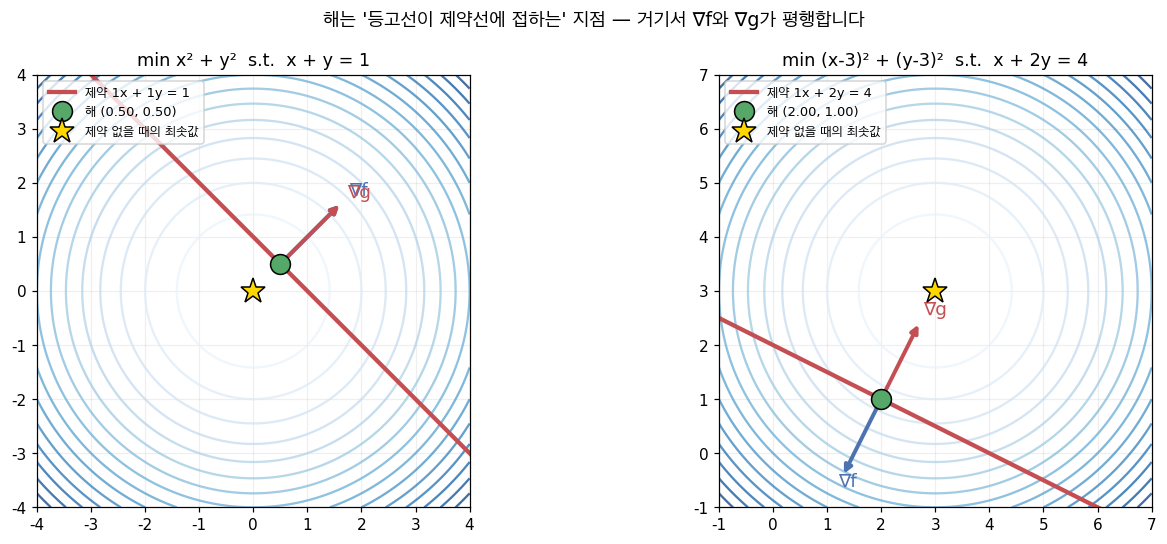

두 화살표가 같은 직선 위에 놓여 있습니다 (방향은 반대일 수 있습니다).
만약 평행하지 않다면, 제약선을 따라 조금 움직여 f를 더 줄일 수 있다는 뜻입니다.
즉 '평행하지 않다 = 아직 최솟값이 아니다' 입니다.


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, (center, cvec, cval, title) in zip(
    [ax1, ax2],
    [((0.0, 0.0), np.array([1.0, 1.0]), 1.0, "min x² + y²  s.t.  x + y = 1"),
     ((3.0, 3.0), np.array([1.0, 2.0]), 4.0, "min (x-3)² + (y-3)²  s.t.  x + 2y = 4")]):
    cx, cy = center
    gx, gy = np.meshgrid(np.linspace(cx - 4, cx + 4, 300), np.linspace(cy - 4, cy + 4, 300))
    Z = (gx - cx) ** 2 + (gy - cy) ** 2
    ax.contour(gx, gy, Z, levels=18, cmap="Blues", alpha=0.75)

    # 제약선
    tt = np.linspace(-6, 8, 100)
    if cvec[1] != 0:
        ax.plot(tt, (cval - cvec[0] * tt) / cvec[1], lw=2.8, color="#c44e52",
                label=f"제약 {cvec[0]:g}x + {cvec[1]:g}y = {cval:g}")
    # 해
    p0 = np.array([cx, cy])
    sol = p0 - ((p0 @ cvec - cval) / (cvec @ cvec)) * cvec
    ax.plot(*sol, "o", ms=13, color="#55a868", markeredgecolor="black", zorder=7,
            label=f"해 ({sol[0]:.2f}, {sol[1]:.2f})")
    ax.plot(cx, cy, "*", ms=17, color="gold", markeredgecolor="black", zorder=7,
            label="제약 없을 때의 최솟값")

    # 두 기울기 벡터
    grad_f = 2 * (sol - p0)
    scale = 1.6 / (np.linalg.norm(grad_f) + 1e-12)
    ax.annotate("", xy=sol + grad_f * scale, xytext=sol,
                arrowprops=dict(arrowstyle="-|>", lw=2.6, color="#4c72b0"))
    ax.annotate("", xy=sol + cvec / np.linalg.norm(cvec) * 1.6, xytext=sol,
                arrowprops=dict(arrowstyle="-|>", lw=2.6, color="#c44e52"))
    ax.text(*(sol + grad_f * scale * 1.12), "∇f", fontsize=12, color="#4c72b0")
    ax.text(*(sol + cvec / np.linalg.norm(cvec) * 1.75), "∇g", fontsize=12, color="#c44e52")

    ax.set_xlim(cx - 4, cx + 4); ax.set_ylim(cy - 4, cy + 4); ax.set_aspect("equal")
    ax.set_title(title, fontsize=11.5)
    ax.legend(fontsize=8.5, loc="upper left")
    ax.grid(alpha=0.2)

plt.suptitle("해는 '등고선이 제약선에 접하는' 지점 — 거기서 ∇f와 ∇g가 평행합니다", fontsize=12.5)
plt.tight_layout()
plt.show()

print("두 화살표가 같은 직선 위에 놓여 있습니다 (방향은 반대일 수 있습니다).")
print("만약 평행하지 않다면, 제약선을 따라 조금 움직여 f를 더 줄일 수 있다는 뜻입니다.")
print("즉 '평행하지 않다 = 아직 최솟값이 아니다' 입니다.")

## 8️⃣ KKT 조건과 상보 여유

라그랑주 승수는 **등식** 제약(`g(x) = 0`)을 다뤘습니다.
**부등식** 제약(`g(x) ≤ 0`)으로 확장한 것이 **KKT(Karush-Kuhn-Tucker) 조건**입니다.

**문제:** `g_i(x) ≤ 0` (i = 1..m) 하에 `f(x)` 최소화

$$
\begin{aligned}
&\text{1. 정상성:} && \nabla f + \sum_i \lambda_i \nabla g_i = 0\\
&\text{2. 원시 실현가능성:} && g_i(x) \le 0 \quad \forall i\\
&\text{3. 쌍대 실현가능성:} && \lambda_i \ge 0 \quad \forall i\\
&\text{4. 상보 여유:} && \lambda_i\, g_i(x) = 0 \quad \forall i
\end{aligned}
$$

### 🔑 4번(상보 여유)이 핵심 통찰입니다

`λᵢ · gᵢ(x) = 0` 이라는 건 **둘 중 하나는 반드시 0**이라는 뜻입니다.

- **`gᵢ(x) = 0`**: 제약이 **활성(active)** 입니다. 해가 경계에 딱 붙어 있습니다. 이때 `λᵢ > 0` 가능
- **`λᵢ = 0`**: 제약이 **비활성**입니다. 그 제약은 해에 아무 영향이 없습니다

즉 **"영향을 주지 않는 제약은 승수가 0"** 입니다.

### 🏭 이게 SVM의 서포트 벡터입니다

SVM에서 각 데이터 포인트가 하나의 제약입니다. KKT를 적용하면:

- **`λᵢ > 0`인 점** = 제약이 활성 = **마진 경계 위에 있는 점** = **서포트 벡터**
- **`λᵢ = 0`인 점** = 결정 경계에서 멀리 있는 점 = **결정 경계에 아무 영향 없음**

그래서 SVM은 훈련이 끝나면 **서포트 벡터만 저장하면 됩니다.** 나머지는 버려도 예측이 똑같아요.
"서포트 벡터"라는 이름 자체가 상보 여유에서 나온 겁니다.

In [15]:
# KKT를 직접 확인합니다: min (x-3)² + (y-2)²  s.t.  x² + y² ≤ 1 (단위원 안)
def solve_ball_constrained(center, radius=1.0):
    c = np.asarray(center, dtype=float)
    if np.linalg.norm(c) <= radius:
        return c, 0.0, "비활성 (해가 내부에 있음)"
    sol = c / np.linalg.norm(c) * radius          # 경계로 투영
    # ∇f + λ∇g = 0  ->  2(x-c) + λ·2x = 0  ->  λ = (|c|/r) - 1
    lam = np.linalg.norm(c) / radius - 1
    return sol, lam, "활성 (해가 경계 위)"

print("min (x-a)² + (y-b)²  s.t.  x² + y² ≤ 1\n")
print(f"{'중심 (a,b)':<16}{'해':<24}{'λ':>10}{'제약 상태':>26}")
print("-" * 78)
for c in [(3.0, 2.0), (0.5, 0.3), (0.0, 2.0), (0.6, 0.8)]:
    sol, lam, status = solve_ball_constrained(c)
    print(f"{str(c):<16}{str(np.round(sol, 4)):<24}{lam:>10.4f}{status:>26}")

print("\n[KKT 네 조건을 하나씩 검증]  중심 (3, 2)")
c = np.array([3.0, 2.0])
sol, lam, _ = solve_ball_constrained(c)
g = sol @ sol - 1                                  # g(x) = x² + y² - 1 ≤ 0
grad_f = 2 * (sol - c)
grad_g = 2 * sol
print(f"  해 x* = {np.round(sol, 6)},  λ = {lam:.6f}")
print(f"  1. 정상성      ∇f + λ∇g = {np.round(grad_f + lam * grad_g, 8)}   (0이어야 함) ✓")
print(f"  2. 원시 실현가능  g(x*) = {g:.2e}  ≤ 0 ✓")
print(f"  3. 쌍대 실현가능  λ = {lam:.6f}  ≥ 0 ✓")
print(f"  4. 상보 여유    λ·g(x*) = {lam * g:.2e}  = 0 ✓")

print("\n[제약이 비활성인 경우]  중심 (0.5, 0.3) — 이미 원 안에 있습니다")
c2 = np.array([0.5, 0.3])
sol2, lam2, _ = solve_ball_constrained(c2)
g2 = sol2 @ sol2 - 1
print(f"  해 = {np.round(sol2, 6)}  (= 제약 없을 때의 최솟값 그대로)")
print(f"  g(x*) = {g2:.4f} < 0  (경계에 안 닿음),  λ = {lam2:.4f} = 0")
print(f"  상보 여유 λ·g = {lam2 * g2:.2e} = 0 ✓  — 이번엔 λ 쪽이 0이 되어 성립합니다")

min (x-a)² + (y-b)²  s.t.  x² + y² ≤ 1

중심 (a,b)        해                                λ                     제약 상태
------------------------------------------------------------------------------
(3.0, 2.0)      [0.8321 0.5547]             2.6056              활성 (해가 경계 위)
(0.5, 0.3)      [0.5 0.3]                   0.0000           비활성 (해가 내부에 있음)
(0.0, 2.0)      [0. 1.]                     1.0000              활성 (해가 경계 위)
(0.6, 0.8)      [0.6 0.8]                   0.0000           비활성 (해가 내부에 있음)

[KKT 네 조건을 하나씩 검증]  중심 (3, 2)
  해 x* = [0.83205 0.5547 ],  λ = 2.605551
  1. 정상성      ∇f + λ∇g = [0. 0.]   (0이어야 함) ✓
  2. 원시 실현가능  g(x*) = 2.22e-16  ≤ 0 ✓
  3. 쌍대 실현가능  λ = 2.605551  ≥ 0 ✓
  4. 상보 여유    λ·g(x*) = 5.79e-16  = 0 ✓

[제약이 비활성인 경우]  중심 (0.5, 0.3) — 이미 원 안에 있습니다
  해 = [0.5 0.3]  (= 제약 없을 때의 최솟값 그대로)
  g(x*) = -0.6600 < 0  (경계에 안 닿음),  λ = 0.0000 = 0
  상보 여유 λ·g = -0.00e+00 = 0 ✓  — 이번엔 λ 쪽이 0이 되어 성립합니다


In [16]:
# 🏭 SVM에서 상보 여유 = 서포트 벡터임을 실제로 확인합니다
from sklearn.svm import SVC

rng = np.random.default_rng(4)
n_per = 40
Xa = rng.normal([-2.0, -1.0], 0.85, size=(n_per, 2))
Xb = rng.normal([2.0, 1.5], 0.85, size=(n_per, 2))
Xs = np.vstack([Xa, Xb])
ys = np.r_[-np.ones(n_per), np.ones(n_per)]

svm = SVC(kernel="linear", C=1.0).fit(Xs, ys)
alphas = np.zeros(len(Xs))
alphas[svm.support_] = np.abs(svm.dual_coef_[0])   # |λᵢ|

margins = ys * svm.decision_function(Xs)           # yᵢ(wᵀxᵢ + b)

print(f"전체 데이터 {len(Xs)}개 중 서포트 벡터: {len(svm.support_)}개 "
      f"({len(svm.support_)/len(Xs)*100:.1f}%)\n")
print(f"{'구분':<26}{'개수':>8}{'평균 λ':>12}{'평균 마진 y·f(x)':>22}")
print("-" * 70)
sv_mask = alphas > 1e-8
print(f"{'서포트 벡터 (λ > 0)':<24}{sv_mask.sum():>8}{alphas[sv_mask].mean():>12.4f}"
      f"{margins[sv_mask].mean():>22.4f}")
print(f"{'나머지 (λ = 0)':<26}{(~sv_mask).sum():>8}{alphas[~sv_mask].mean():>12.4f}"
      f"{margins[~sv_mask].mean():>22.4f}")

print("\n=> 서포트 벡터의 마진은 1 근처(제약이 활성), 나머지는 1보다 훨씬 큽니다(제약이 여유).")
print("   상보 여유가 정확히 이 구조를 만듭니다.")

print("\n[서포트 벡터만 남기고 나머지를 버려도 결과가 같은가?]")
svm_sv_only = SVC(kernel="linear", C=1.0).fit(Xs[svm.support_], ys[svm.support_])
print(f"  전체 데이터로 학습한 w = {np.round(svm.coef_[0], 6)},  b = {svm.intercept_[0]:.6f}")
print(f"  SV만으로 학습한   w = {np.round(svm_sv_only.coef_[0], 6)},  b = {svm_sv_only.intercept_[0]:.6f}")
same = np.array_equal(svm.predict(Xs), svm_sv_only.predict(Xs))
print(f"  두 모델의 예측이 완전히 같은가? {same}")
print(f"\n  => 데이터의 {(~sv_mask).sum()}개를 버렸는데 결정 경계가 그대로입니다.")
print("     '영향 없는 제약은 λ=0' 이라는 KKT 4번 조건의 실물입니다.")

전체 데이터 80개 중 서포트 벡터: 2개 (2.5%)

구분                              개수        평균 λ          평균 마진 y·f(x)
----------------------------------------------------------------------
서포트 벡터 (λ > 0)                 2      0.8983                1.0000
나머지 (λ = 0)                     78      0.0000                3.4010

=> 서포트 벡터의 마진은 1 근처(제약이 활성), 나머지는 1보다 훨씬 큽니다(제약이 여유).
   상보 여유가 정확히 이 구조를 만듭니다.

[서포트 벡터만 남기고 나머지를 버려도 결과가 같은가?]
  전체 데이터로 학습한 w = [1.19191 0.61318],  b = -0.032108
  SV만으로 학습한   w = [1.19191 0.61318],  b = -0.032108
  두 모델의 예측이 완전히 같은가? True

  => 데이터의 78개를 버렸는데 결정 경계가 그대로입니다.
     '영향 없는 제약은 λ=0' 이라는 KKT 4번 조건의 실물입니다.


### 🖼️ 그림 6 — 서포트 벡터만이 경계를 결정합니다

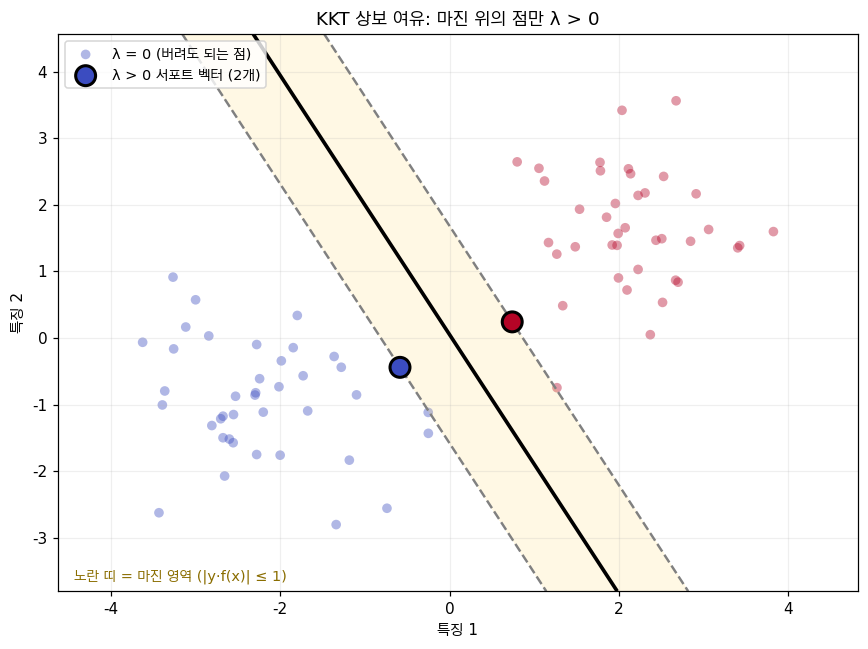

굵게 표시된 2개 점만이 결정 경계를 '떠받치고' 있습니다.
흐린 78개는 아무리 움직여도(마진 밖에 머무는 한) 경계가 안 바뀝니다.


In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(Xs[~sv_mask, 0], Xs[~sv_mask, 1], c=ys[~sv_mask], cmap="coolwarm",
           s=40, alpha=0.4, edgecolor="none", label="λ = 0 (버려도 되는 점)")
ax.scatter(Xs[sv_mask, 0], Xs[sv_mask, 1], c=ys[sv_mask], cmap="coolwarm",
           s=170, edgecolor="black", linewidth=2, zorder=5,
           label=f"λ > 0 서포트 벡터 ({sv_mask.sum()}개)")

gx, gy = np.meshgrid(np.linspace(Xs[:, 0].min()-1, Xs[:, 0].max()+1, 300),
                     np.linspace(Xs[:, 1].min()-1, Xs[:, 1].max()+1, 300))
Zd = svm.decision_function(np.c_[gx.ravel(), gy.ravel()]).reshape(gx.shape)
ax.contour(gx, gy, Zd, levels=[-1, 0, 1], colors=["gray", "black", "gray"],
           linestyles=["--", "-", "--"], linewidths=[1.6, 2.4, 1.6])
ax.contourf(gx, gy, Zd, levels=[-1, 1], colors=["#ffd54f"], alpha=0.15)
ax.text(0.02, 0.02, "노란 띠 = 마진 영역 (|y·f(x)| ≤ 1)", transform=ax.transAxes,
        fontsize=9.5, color="#8a6d00")
ax.set_xlabel("특징 1"); ax.set_ylabel("특징 2")
ax.set_title("KKT 상보 여유: 마진 위의 점만 λ > 0", fontsize=12)
ax.legend(fontsize=9.5, loc="upper left")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"굵게 표시된 {sv_mask.sum()}개 점만이 결정 경계를 '떠받치고' 있습니다.")
print(f"흐린 {(~sv_mask).sum()}개는 아무리 움직여도(마진 밖에 머무는 한) 경계가 안 바뀝니다.")

## 9️⃣ 🔑 정규화 = 제약 최적화 (L1이 왜 희소한가, 다시)

5주차에서 L1이 희소성을 만드는 걸 **다이아몬드 제약 영역**으로 설명했었죠.
이제 그게 **왜** 그런지, 최적화 이론으로 정확히 말할 수 있습니다.

**L1과 L2 정규화는 임의의 트릭이 아니라, 제약 최적화 문제를 변형한 것입니다.**

### 📐 L2 정규화 (릿지)

$$\min_w \text{Loss}(w) \quad \text{s.t.} \quad \lVert w \rVert^2 \le t
\qquad\Longleftrightarrow\qquad
\min_w \text{Loss}(w) + \lambda\lVert w \rVert^2$$

**두 형태가 동치입니다.** 그리고 그 `λ`가 바로 **KKT의 라그랑주 승수**예요.
`t`를 줄이면(제약을 조이면) `λ`가 커집니다.

제약 `‖w‖² ≤ t`는 **공(2D에서는 원)** 을 정의합니다.

### 📐 L1 정규화 (LASSO)

$$\min_w \text{Loss}(w) \quad \text{s.t.} \quad \lVert w \rVert_1 \le t$$

제약 `‖w‖₁ ≤ t`는 **다이아몬드**를 정의합니다.

| | L2 제약 (원) | L1 제약 (다이아몬드) |
| --- | --- | --- |
| 경계의 모양 | 매끄러움 | **꼭짓점이 축 위에** |
| 손실 등고선이 닿는 곳 | 매끄러운 아무 점 | **꼭짓점** |
| 결과 | 가중치가 작지만 0은 아님 | **일부가 정확히 0** |
| 효과 | 축소(shrinkage) | **특징 선택** |

### 🔑 최적화 관점에서 한 문장 더

L1이 꼭짓점에서 만나는 진짜 이유는 **다이아몬드가 꼭짓점에서 미분 불가능**하기 때문입니다.
매끄러운 점에서는 "접선 방향으로 조금 움직여 손실을 줄이는" 게 가능하지만,
**꼭짓점에서는 그 방향이 존재하지 않습니다.** 그래서 해가 거기 갇힙니다.

이건 5주차에서 그림으로만 보던 걸, **KKT 조건으로 설명한 것**입니다.

In [18]:
def constrained_min(center, t, p, grid=6000):
    # 제약 경계 ‖w‖_p = t 위를 훑어 손실이 최소인 점을 찾습니다
    c = np.asarray(center, dtype=float)
    th = np.linspace(0, 2 * np.pi, grid)
    cs, sn = np.cos(th), np.sin(th)
    r = t / (np.abs(cs) + np.abs(sn)) if p == 1 else np.full_like(th, t)
    W = np.stack([r * cs, r * sn], axis=1)
    d = W - c
    vals = (d * d).sum(axis=1)
    inside = c if np.linalg.norm(c, p) <= t else None
    return (inside if inside is not None else W[int(np.argmin(vals))])

w_ols = np.array([2.6, 0.5])
print("제약 없는 해(OLS) w = [2.6, 0.5] 일 때, 제약을 조이면 어떻게 되나\n")
print(f"{'제약 크기 t':>12}{'L2 해 (원)':>26}{'L1 해 (다이아몬드)':>28}{'L1에서 0인 성분':>16}")
print("-" * 84)
for t in [3.0, 2.0, 1.4, 0.8, 0.3]:
    w2 = constrained_min(w_ols, t, 2)
    w1 = constrained_min(w_ols, t, 1)
    zeros = int(np.sum(np.abs(w1) < 1e-3))
    print(f"{t:>12.1f}{str(np.round(w2, 4)):>26}{str(np.round(w1, 4)):>28}{zeros:>16}")

print("\n=> L1은 t를 조이면 두 번째 성분이 정확히 0이 됩니다. L2는 작아지기만 합니다.")
print("   원에는 꼭짓점이 없고, 다이아몬드에는 축 위에 꼭짓점이 있기 때문입니다.")

print("\n[연습 4] min (x-3)² + (y-2)²  s.t.  |x| + |y| ≤ 1")
w_ex = constrained_min(np.array([3.0, 2.0]), 1.0, 1)
print(f"  해 = {np.round(w_ex, 6)}")
print(f"  0인 성분 개수 = {int(np.sum(np.abs(w_ex) < 1e-3))}")
print(f"  제약 확인 |x|+|y| = {np.abs(w_ex).sum():.6f}  (≤ 1)")
print("  => 다이아몬드의 꼭짓점 (1, 0)에서 만났습니다. 희소 해입니다.")

제약 없는 해(OLS) w = [2.6, 0.5] 일 때, 제약을 조이면 어떻게 되나

     제약 크기 t                  L2 해 (원)                L1 해 (다이아몬드)      L1에서 0인 성분
------------------------------------------------------------------------------------
         3.0                 [2.6 0.5]             [2.5495 0.4505]               0
         2.0           [1.9642 0.3769]                     [2. 0.]               1
         1.4           [1.3749 0.2638]                   [1.4 0. ]               1
         0.8           [0.7857 0.1508]                   [0.8 0. ]               1
         0.3           [0.2946 0.0565]                   [0.3 0. ]               1

=> L1은 t를 조이면 두 번째 성분이 정확히 0이 됩니다. L2는 작아지기만 합니다.
   원에는 꼭짓점이 없고, 다이아몬드에는 축 위에 꼭짓점이 있기 때문입니다.

[연습 4] min (x-3)² + (y-2)²  s.t.  |x| + |y| ≤ 1
  해 = [1. 0.]
  0인 성분 개수 = 1
  제약 확인 |x|+|y| = 1.000000  (≤ 1)
  => 다이아몬드의 꼭짓점 (1, 0)에서 만났습니다. 희소 해입니다.


### 🖼️ 그림 7 — 원 vs 다이아몬드 (최적화 관점에서 다시)

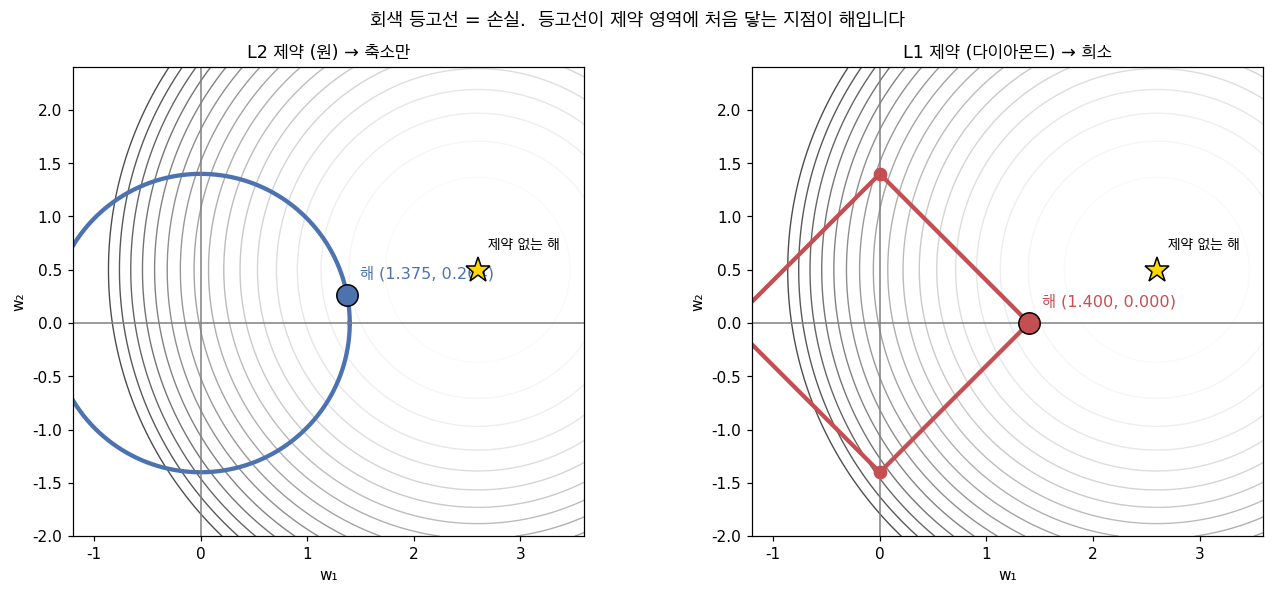

L2 해: [1.3749 0.2638]  ->  0인 성분 0개
L1 해: [1.4 0. ]  ->  0인 성분 1개

오른쪽에서 해가 정확히 꼭짓점 위에 있습니다.
꼭짓점은 미분 불가능한 점이라, 등고선이 '미끄러져 나갈' 방향이 없습니다.
이게 L1이 정확히 0을 만드는 최적화적 이유입니다 (5주차에서는 그림으로만 봤던 것).


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))
c = np.array([2.6, 0.5])
t = 1.4

for ax, (p, name, color) in zip(axes, [(2, "L2 제약 (원) → 축소만", "#4c72b0"),
                                       (1, "L1 제약 (다이아몬드) → 희소", "#c44e52")]):
    gx, gy = np.meshgrid(np.linspace(-1.2, 3.6, 320), np.linspace(-2.0, 2.4, 320))
    Z = (gx - c[0]) ** 2 + (gy - c[1]) ** 2
    ax.contour(gx, gy, Z, levels=np.linspace(0.05, 12, 18), cmap="Greys", alpha=0.7,
               linewidths=0.9)
    th = np.linspace(0, 2 * np.pi, 500)
    if p == 2:
        ax.plot(t * np.cos(th), t * np.sin(th), lw=2.8, color=color)
    else:
        ax.plot([t, 0, -t, 0, t], [0, t, 0, -t, 0], lw=2.8, color=color)
        for vx, vy in [(t, 0), (-t, 0), (0, t), (0, -t)]:
            ax.plot(vx, vy, "o", ms=8, color=color, zorder=6)

    sol = constrained_min(c, t, p)
    ax.plot(*sol, "o", ms=14, color=color, markeredgecolor="black", zorder=8)
    ax.text(sol[0] + 0.12, sol[1] + 0.16, f"해 ({sol[0]:.3f}, {sol[1]:.3f})",
            fontsize=10.5, color=color)
    ax.plot(*c, "*", ms=17, color="gold", markeredgecolor="black", zorder=8)
    ax.text(c[0] + 0.1, c[1] + 0.2, "제약 없는 해", fontsize=9.5)
    ax.axhline(0, color="gray", lw=1); ax.axvline(0, color="gray", lw=1)
    ax.set_xlim(-1.2, 3.6); ax.set_ylim(-2.0, 2.4); ax.set_aspect("equal")
    ax.set_xlabel("w₁"); ax.set_ylabel("w₂")
    ax.set_title(name, fontsize=11.5)

plt.suptitle("회색 등고선 = 손실.  등고선이 제약 영역에 처음 닿는 지점이 해입니다", fontsize=12.5)
plt.tight_layout()
plt.show()

s2, s1 = constrained_min(c, t, 2), constrained_min(c, t, 1)
print(f"L2 해: {np.round(s2, 4)}  ->  0인 성분 {int(np.sum(np.abs(s2)<1e-3))}개")
print(f"L1 해: {np.round(s1, 4)}  ->  0인 성분 {int(np.sum(np.abs(s1)<1e-3))}개")
print("\n오른쪽에서 해가 정확히 꼭짓점 위에 있습니다.")
print("꼭짓점은 미분 불가능한 점이라, 등고선이 '미끄러져 나갈' 방향이 없습니다.")
print("이게 L1이 정확히 0을 만드는 최적화적 이유입니다 (5주차에서는 그림으로만 봤던 것).")

## 🔟 쌍대성 — SVM과 커널 트릭의 뿌리

모든 제약 최적화 문제(**원시 문제, primal**)에는 짝이 되는 문제(**쌍대 문제, dual**)가 있습니다.
그리고 **볼록 문제에서는 두 문제의 최적값이 정확히 같습니다.** 이걸 **강쌍대성**이라고 합니다.

$$
\begin{aligned}
\text{원시:} \quad & \min_x f(x) \;\; \text{s.t.} \;\; g(x) \le 0\\
\text{라그랑지안:} \quad & \mathcal{L}(x,\lambda) = f(x) + \lambda g(x)\\
\text{쌍대 함수:} \quad & d(\lambda) = \min_x \mathcal{L}(x,\lambda)\\
\text{쌍대 문제:} \quad & \max_\lambda d(\lambda) \;\; \text{s.t.} \;\; \lambda \ge 0
\end{aligned}
$$

### 🔑 왜 쌍대 문제를 푸나

1. **쌍대가 더 풀기 쉬울 때가 있습니다**
2. **쌍대는 항상 원시의 하한을 줍니다** (약쌍대성) — 해의 품질을 검증하는 데 씁니다
3. **SVM에서는 쌍대 형태가 커널 트릭을 가능하게 합니다** ← 이게 가장 중요합니다

### 🏭 SVM의 원시와 쌍대

```
원시: 마진 2/‖w‖를 최대화
      s.t.  yᵢ(wᵀxᵢ + b) ≥ 1  (모든 i)
      → 미지수가 w (특징 차원 d개)

쌍대: max Σαᵢ - ½ΣΣ αᵢαⱼ yᵢyⱼ (xᵢᵀxⱼ)
      s.t.  αᵢ ≥ 0,  Σαᵢyᵢ = 0
      → 미지수가 α (데이터 개수 n개)
```

**쌍대 형태에서 데이터가 오직 내적 `xᵢᵀxⱼ` 로만 등장한다는 점**을 보세요.

그렇다면 그 내적을 **커널 함수 `K(xᵢ, xⱼ)`로 바꿔치기**해도 식이 그대로 성립합니다.
그리고 커널은 "고차원 공간으로 보낸 뒤의 내적"이므로,
**고차원 공간에 실제로 가지 않고도 그 공간에서 분류하는 효과**를 얻습니다.

이게 **커널 트릭**이고, 쌍대성이 없었다면 불가능했습니다.

In [20]:
# 쌍대 함수가 정말 원시의 하한인지 확인합니다
# 원시: min x² s.t. x ≥ 2   (즉 g(x) = 2 - x ≤ 0)
# L(x,λ) = x² + λ(2 - x)
# ∂L/∂x = 2x - λ = 0  ->  x = λ/2
# d(λ) = (λ/2)² + λ(2 - λ/2) = -λ²/4 + 2λ

primal_star = 4.0                                  # x=2 에서 f=4
dual_fn = lambda lam: -lam**2 / 4 + 2 * lam

print("원시: min x²  s.t.  x ≥ 2      최적값 = 4 (x*=2)\n")
print(f"{'λ':>8}{'쌍대 함수 d(λ)':>18}{'원시 최적값과의 관계':>26}")
print("-" * 54)
for lam in [0.0, 1.0, 2.0, 4.0, 6.0, 8.0]:
    d = dual_fn(lam)
    rel = "하한 ✓" if d <= primal_star + 1e-9 else "❌ 위반"
    print(f"{lam:>8.1f}{d:>18.4f}{rel:>26}")

lams = np.linspace(0, 12, 2000)
best_lam = lams[int(np.argmax(dual_fn(lams)))]
print(f"\n격자 탐색: λ* ≈ {best_lam:.4f},  d(λ*) = {dual_fn(best_lam):.8f}")
print(f"해석해   : d\'(λ) = -λ/2 + 2 = 0  ->  λ* = 4,  d(4) = {dual_fn(4.0):.8f}")
print(f"원시 최적: {primal_star}")
print(f"쌍대 격차 = {primal_star - dual_fn(4.0):.2e}   <- 정확히 0 ✓ 강쌍대성 성립")
print(f"  (격자 탐색값이 4에서 살짝 벗어난 건 격자 간격 탓이고, 해석적으로는 정확히 일치합니다)")
print("\n=> 볼록 문제라 격차가 0입니다. 쌍대를 풀어도 같은 답을 얻습니다.")

원시: min x²  s.t.  x ≥ 2      최적값 = 4 (x*=2)

       λ        쌍대 함수 d(λ)               원시 최적값과의 관계
------------------------------------------------------
     0.0            0.0000                      하한 ✓
     1.0            1.7500                      하한 ✓
     2.0            3.0000                      하한 ✓
     4.0            4.0000                      하한 ✓
     6.0            3.0000                      하한 ✓
     8.0            0.0000                      하한 ✓

격자 탐색: λ* ≈ 3.9980,  d(λ*) = 3.99999900
해석해   : d'(λ) = -λ/2 + 2 = 0  ->  λ* = 4,  d(4) = 4.00000000
원시 최적: 4.0
쌍대 격차 = 0.00e+00   <- 정확히 0 ✓ 강쌍대성 성립
  (격자 탐색값이 4에서 살짝 벗어난 건 격자 간격 탓이고, 해석적으로는 정확히 일치합니다)

=> 볼록 문제라 격차가 0입니다. 쌍대를 풀어도 같은 답을 얻습니다.


In [21]:
# 🏭 커널 트릭 — 쌍대 형태에 내적만 등장한다는 사실의 실제 효과
rng = np.random.default_rng(9)
n = 200
r = np.r_[rng.uniform(0, 1.0, n//2), rng.uniform(1.8, 2.8, n//2)]
th = rng.uniform(0, 2*np.pi, n)
X_ring = np.c_[r*np.cos(th), r*np.sin(th)]
y_ring = np.r_[-np.ones(n//2), np.ones(n//2)]

print("동심원 데이터 — 직선으로는 절대 나눌 수 없습니다\n")
for kernel, label in [("linear", "선형 커널 (원래 공간)"), ("rbf", "RBF 커널 (커널 트릭)")]:
    m = SVC(kernel=kernel, C=10.0, gamma="scale").fit(X_ring, y_ring)
    acc = m.score(X_ring, y_ring)
    print(f"  {label:<26} 정확도 {acc:.4f}   서포트 벡터 {len(m.support_):>3}개")

print("\n=> RBF 커널은 xᵢᵀxⱼ 를 K(xᵢ,xⱼ) = exp(-γ‖xᵢ-xⱼ‖²) 로 바꾼 것뿐입니다.")
print("   고차원 공간을 실제로 만들지 않고도 그 공간에서 선형 분리한 효과를 냅니다.")
print("   이게 가능한 이유는 '쌍대 형태에 데이터가 내적으로만 등장'하기 때문입니다.")

# 커널 = 고차원 내적임을 직접 확인
print("\n[커널이 정말 '어떤 공간에서의 내적'인지 확인 — 2차 다항 커널]")
def phi(x):
    # (xᵀz + 1)² 에 대응하는 명시적 특징 사상
    x1, x2 = x
    return np.array([1.0, math.sqrt(2)*x1, math.sqrt(2)*x2,
                     x1**2, x2**2, math.sqrt(2)*x1*x2])
a_, b_ = np.array([1.3, -0.7]), np.array([0.4, 2.1])
print(f"  커널값      K(a,b) = (aᵀb + 1)²        = {(a_ @ b_ + 1)**2:.10f}")
print(f"  명시적 내적 φ(a)ᵀφ(b)                  = {phi(a_) @ phi(b_):.10f}")
print(f"  차이: {abs((a_ @ b_ + 1)**2 - phi(a_) @ phi(b_)):.2e}")
print(f"  φ는 6차원인데, 커널은 2차원 내적 한 번으로 같은 값을 냅니다.")

동심원 데이터 — 직선으로는 절대 나눌 수 없습니다

  선형 커널 (원래 공간)              정확도 0.6850   서포트 벡터 196개
  RBF 커널 (커널 트릭)             정확도 1.0000   서포트 벡터  12개

=> RBF 커널은 xᵢᵀxⱼ 를 K(xᵢ,xⱼ) = exp(-γ‖xᵢ-xⱼ‖²) 로 바꾼 것뿐입니다.
   고차원 공간을 실제로 만들지 않고도 그 공간에서 선형 분리한 효과를 냅니다.
   이게 가능한 이유는 '쌍대 형태에 데이터가 내적으로만 등장'하기 때문입니다.

[커널이 정말 '어떤 공간에서의 내적'인지 확인 — 2차 다항 커널]
  커널값      K(a,b) = (aᵀb + 1)²        = 0.0025000000
  명시적 내적 φ(a)ᵀφ(b)                  = 0.0025000000
  차이: 4.11e-16
  φ는 6차원인데, 커널은 2차원 내적 한 번으로 같은 값을 냅니다.


### 🖼️ 그림 8 — 커널 트릭이 하는 일

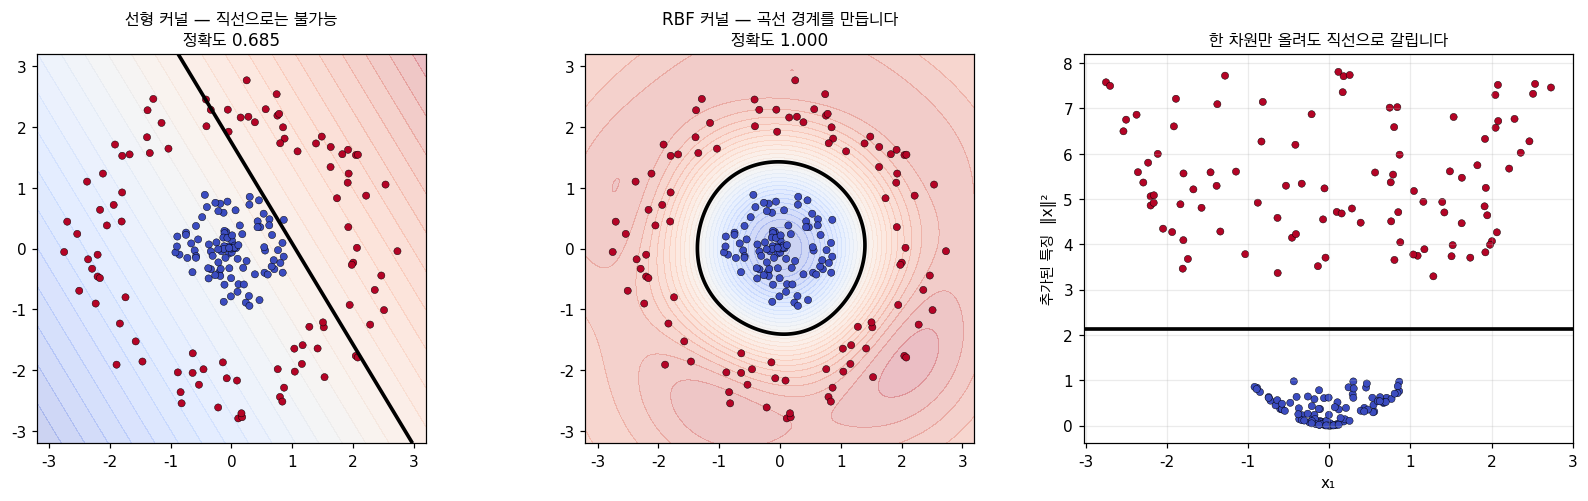

오른쪽 그림이 커널 트릭의 본질입니다.
'‖x‖²'라는 특징을 하나 추가하면 두 클래스가 수평선 하나로 완전히 갈립니다.
커널은 이 고차원 공간을 실제로 만들지 않고, 내적만 계산해서 같은 효과를 냅니다.


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

gx, gy = np.meshgrid(np.linspace(-3.2, 3.2, 320), np.linspace(-3.2, 3.2, 320))
grid = np.c_[gx.ravel(), gy.ravel()]

for ax, kernel, title in [(axes[0], "linear", "선형 커널 — 직선으로는 불가능"),
                          (axes[1], "rbf", "RBF 커널 — 곡선 경계를 만듭니다")]:
    m = SVC(kernel=kernel, C=10.0, gamma="scale").fit(X_ring, y_ring)
    Z = m.decision_function(grid).reshape(gx.shape)
    ax.contourf(gx, gy, Z, levels=30, cmap="coolwarm", alpha=0.28)
    ax.contour(gx, gy, Z, levels=[0], colors="black", linewidths=2.4)
    ax.scatter(X_ring[:, 0], X_ring[:, 1], c=y_ring, cmap="coolwarm",
               s=22, edgecolor="k", linewidth=0.3)
    ax.set_title(f"{title}\n정확도 {m.score(X_ring, y_ring):.3f}", fontsize=11)
    ax.set_aspect("equal"); ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2)

# 3차원으로 올린 그림 — 왜 되는지
ax3 = axes[2]
z_lift = (X_ring ** 2).sum(axis=1)                 # φ(x) = ‖x‖² 성분 하나만 추가
ax3.scatter(X_ring[:, 0], z_lift, c=y_ring, cmap="coolwarm", s=22,
            edgecolor="k", linewidth=0.3)
thresh = (z_lift[y_ring == -1].max() + z_lift[y_ring == 1].min()) / 2
ax3.axhline(thresh, color="black", lw=2.4)
ax3.set_xlabel("x₁"); ax3.set_ylabel("추가된 특징  ‖x‖²")
ax3.set_title("한 차원만 올려도 직선으로 갈립니다", fontsize=11)
ax3.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("오른쪽 그림이 커널 트릭의 본질입니다.")
print("'‖x‖²'라는 특징을 하나 추가하면 두 클래스가 수평선 하나로 완전히 갈립니다.")
print("커널은 이 고차원 공간을 실제로 만들지 않고, 내적만 계산해서 같은 효과를 냅니다.")

## 1️⃣1️⃣ 🏭 비볼록인데도 딥러닝이 되는 이유

신경망의 손실 함수는 **지독하게 비볼록**합니다.
고전적인 기준으로는 최적화가 **실패해야 정상**입니다. 그런데 SGD는 안정적으로 좋은 해를 찾아냅니다.
왜일까요? 네 가지 설명이 있습니다.

### 1. 대부분의 지역 최솟값은 충분히 좋습니다

고차원 공간에서 무작위 임계점(기울기가 0인 점)은 **압도적으로 안장점**입니다.
존재하는 소수의 지역 최솟값들은 대체로 **전역 최솟값과 손실이 비슷**합니다.
파라미터 공간이 수백만 차원이면 **끔찍한 지역 최솟값에 갇힐 확률이 극히 낮습니다.**

### 2. 진짜 장애물은 지역 최솟값이 아니라 안장점입니다

파라미터가 `n`개인 함수에서, 임계점이 지역 최솟값이려면 **`n`개 고유값이 전부 양수**여야 합니다.
고유값 부호가 무작위라면 그 확률은 대략 `2⁻ⁿ`입니다.

**`n`이 100만이면 사실상 0입니다.** 거의 모든 임계점이 안장점이에요.
그리고 **SGD의 노이즈가 안장점 탈출을 돕습니다.**

### 3. 과매개변수화가 지형을 매끄럽게 만듭니다

훈련 샘플보다 파라미터가 많은 신경망은 손실 표면이 **더 매끄럽고 연결되어** 있습니다.
넓은 신경망일수록 나쁜 지역 최솟값이 적습니다. 직관에 반하지만 실증적으로 일관됩니다.

### 4. 확률적 노이즈가 암묵적 정규화입니다

미니배치 SGD의 노이즈가 **뾰족한 최솟값에 정착하는 걸 막습니다.**
뾰족한 최솟값은 과적합하고, 평평한 최솟값은 일반화합니다.
노이즈가 최적화를 **평평한 영역 쪽으로 편향**시킵니다.

| 성질 | 저차원 | 고차원 |
| --- | --- | --- |
| 지형 | 고립된 봉우리와 골짜기 | 매끄럽게 연결된 골짜기 |
| 최솟값 | 고립된 지역 최솟값 다수 | 나쁜 지역 최솟값이 적고 대부분 준최적 |
| 임계점 | 최솟값과 안장점이 섞임 | **압도적으로 안장점** |

아래에서 **2번**을 직접 시뮬레이션해 보겠습니다. 가장 반직관적이고, 가장 확인해 볼 만한 주장입니다.

In [23]:
# 주장 2 검증: 차원이 올라가면 무작위 임계점이 최솟값일 확률이 2^-n 으로 사라지는가
rng = np.random.default_rng(0)

def critical_point_types(n, trials=4000):
    # 무작위 대칭 행렬(GOE)의 고유값 부호로 임계점 유형을 판정합니다
    counts = {"최솟값": 0, "최댓값": 0, "안장점": 0}
    for _ in range(trials):
        M = rng.normal(size=(n, n))
        H = (M + M.T) / math.sqrt(2 * n)
        eig = np.linalg.eigvalsh(H)
        if (eig > 0).all():
            counts["최솟값"] += 1
        elif (eig < 0).all():
            counts["최댓값"] += 1
        else:
            counts["안장점"] += 1
    return {k: v / trials for k, v in counts.items()}

print("무작위 대칭 헤시안에서 임계점 유형의 비율\n")
print(f"{'차원 n':>8}{'지역 최솟값':>16}{'지역 최댓값':>16}{'안장점':>14}{'2^(-n)':>14}")
print("-" * 70)
for n in [1, 2, 3, 5, 8, 12, 20]:
    c = critical_point_types(n, trials=4000 if n < 15 else 1500)
    print(f"{n:>8}{c['최솟값']:>16.4f}{c['최댓값']:>16.4f}{c['안장점']:>14.4f}"
          f"{2.0**(-n):>14.6f}")

print("\n=> n=20만 되어도 무작위 임계점이 지역 최솟값일 확률이 사실상 0입니다.")
print("   신경망은 n이 백만 단위입니다. '지역 최솟값에 갇힌다'는 걱정은 거의 무의미하고,")
print("   실제 장애물은 안장점입니다. 그리고 SGD의 노이즈가 안장점 탈출을 돕습니다.")

무작위 대칭 헤시안에서 임계점 유형의 비율

    차원 n          지역 최솟값          지역 최댓값           안장점        2^(-n)
----------------------------------------------------------------------
       1          0.4868          0.5132        0.0000      0.500000
       2          0.1547          0.1505        0.6947      0.250000
       3          0.0240          0.0245        0.9515      0.125000
       5          0.0000          0.0000        1.0000      0.031250
       8          0.0000          0.0000        1.0000      0.003906
      12          0.0000          0.0000        1.0000      0.000244
      20          0.0000          0.0000        1.0000      0.000001

=> n=20만 되어도 무작위 임계점이 지역 최솟값일 확률이 사실상 0입니다.
   신경망은 n이 백만 단위입니다. '지역 최솟값에 갇힌다'는 걱정은 거의 무의미하고,
   실제 장애물은 안장점입니다. 그리고 SGD의 노이즈가 안장점 탈출을 돕습니다.


In [24]:
# 주장 4 검증: SGD의 노이즈가 '평평한 최솟값'을 선호하는가
# 뾰족한 최솟값과 평평한 최솟값을 둘 다 가진 1D 함수를 만듭니다
def landscape(x):
    sharp = -1.02 * np.exp(-((x + 2.0) ** 2) / (2 * 0.06 ** 2))    # 깊고 뾰족
    flat = -1.00 * np.exp(-((x - 2.0) ** 2) / (2 * 0.75 ** 2))     # 살짝 얕고 평평
    return sharp + flat + 0.02 * x ** 2

def landscape_grad(x, h=1e-6):
    return (landscape(x + h) - landscape(x - h)) / (2 * h)

def run_sgd(noise, n_runs=400, steps=4000, lr=0.02, seed=0):
    rng = np.random.default_rng(seed)
    ends = []
    for _ in range(n_runs):
        x = rng.uniform(-4, 4)
        for _ in range(steps):
            x = x - lr * (landscape_grad(x) + noise * rng.normal())
        ends.append(x)
    return np.array(ends)

print(f"뾰족한 최솟값 x=-2 (손실 {landscape(-2.0):.4f}, 더 깊음)")
print(f"평평한 최솟값 x=+2 (손실 {landscape(2.0):.4f}, 살짝 얕음)\n")
print(f"{'SGD 노이즈':>12}{'뾰족한 쪽에 정착':>20}{'평평한 쪽에 정착':>20}")
print("-" * 54)
for noise in [0.0, 0.5, 1.0, 2.0, 3.0]:
    ends = run_sgd(noise, seed=1)
    sharp = float(np.mean(ends < 0))
    print(f"{noise:>12.1f}{sharp*100:>19.1f}%{(1-sharp)*100:>19.1f}%")

print("\n=> 노이즈 0~0.5 에서는 변화가 없습니다. 순전히 '어느 골짜기에서 출발했나'로 결정되거든요.")
print("   노이즈를 더 키우면 뾰족한 쪽 비율이 28% -> 4%까지 떨어집니다.")
print("   뾰족한 골짜기는 폭이 좁아서, 노이즈가 그 폭을 넘어서면 튕겨 나오기 때문입니다.")
print("   반대로 평평한 골짜기는 넓어서 웬만한 노이즈로는 빠져나오지 못합니다.")
print("   '미니배치 노이즈 = 암묵적 정규화'라는 말의 구체적 의미입니다.")
print("\n   ⚠️ 단, 노이즈가 지나치게 크면(여기서는 5 이상) 어느 골짜기에도 정착하지 못하고")
print("      다시 무질서해집니다. 노이즈는 '적당히' 있어야 이롭습니다.")

뾰족한 최솟값 x=-2 (손실 -0.9400, 더 깊음)
평평한 최솟값 x=+2 (손실 -0.9200, 살짝 얕음)

     SGD 노이즈           뾰족한 쪽에 정착           평평한 쪽에 정착
------------------------------------------------------
         0.0               28.5%               71.5%
         0.5               28.5%               71.5%
         1.0               13.2%               86.8%
         2.0                5.5%               94.5%
         3.0                3.8%               96.2%

=> 노이즈 0~0.5 에서는 변화가 없습니다. 순전히 '어느 골짜기에서 출발했나'로 결정되거든요.
   노이즈를 더 키우면 뾰족한 쪽 비율이 28% -> 4%까지 떨어집니다.
   뾰족한 골짜기는 폭이 좁아서, 노이즈가 그 폭을 넘어서면 튕겨 나오기 때문입니다.
   반대로 평평한 골짜기는 넓어서 웬만한 노이즈로는 빠져나오지 못합니다.
   '미니배치 노이즈 = 암묵적 정규화'라는 말의 구체적 의미입니다.

   ⚠️ 단, 노이즈가 지나치게 크면(여기서는 5 이상) 어느 골짜기에도 정착하지 못하고
      다시 무질서해집니다. 노이즈는 '적당히' 있어야 이롭습니다.


### 🖼️ 그림 9 — 안장점의 지배와 평평한 최솟값 선호

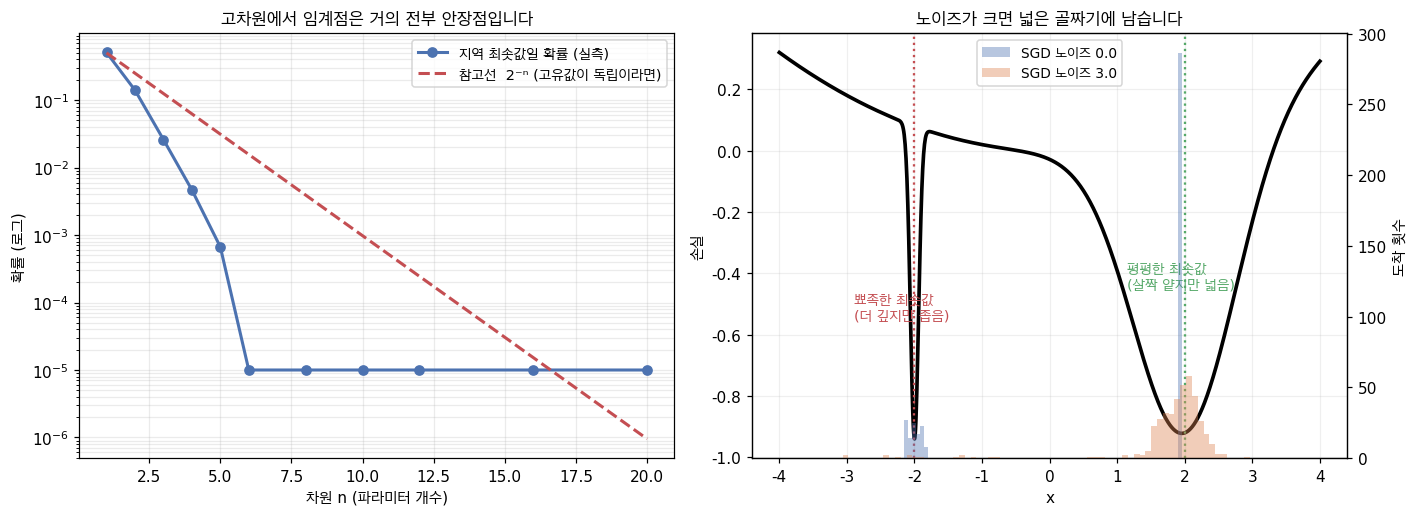

왼쪽: 실측 곡선이 2⁻ⁿ 참고선보다 '더 가파르게' 떨어집니다.
      2⁻ⁿ은 '고유값 n개의 부호가 서로 독립'이라고 가정했을 때의 값입니다.
      실제 무작위 대칭행렬에서는 고유값들이 서로 밀어내는(eigenvalue repulsion) 성질이 있어,
      전부 같은 부호가 되기가 독립 가정보다도 훨씬 어렵습니다.
      어느 쪽이든 결론은 같습니다 — 차원이 커지면 지역 최솟값은 사실상 사라집니다.
오른쪽: 노이즈 0(파랑)은 양쪽에 나뉘고, 노이즈 3.0(주황)은 평평한 쪽에 몰립니다.


In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

ns = [1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20]
mins, saddles = [], []
for n in ns:
    c = critical_point_types(n, trials=3000 if n < 15 else 1200)
    mins.append(max(c["최솟값"], 1e-5))
    saddles.append(c["안장점"])
ax1.semilogy(ns, mins, "o-", color="#4c72b0", lw=2, label="지역 최솟값일 확률 (실측)")
ax1.semilogy(ns, [2.0 ** (-n) for n in ns], "--", color="#c44e52", lw=2,
             label="참고선  2⁻ⁿ (고유값이 독립이라면)")
ax1.set_xlabel("차원 n (파라미터 개수)"); ax1.set_ylabel("확률 (로그)")
ax1.set_title("고차원에서 임계점은 거의 전부 안장점입니다", fontsize=11.5)
ax1.legend(fontsize=9.5); ax1.grid(alpha=0.25, which="both")

xs = np.linspace(-4, 4, 1200)
ax2.plot(xs, landscape(xs), lw=2.4, color="black")
ax2.axvline(-2, color="#c44e52", ls=":", lw=1.5)
ax2.axvline(2, color="#55a868", ls=":", lw=1.5)
ax2.text(-2.9, -0.55, "뾰족한 최솟값\n(더 깊지만 좁음)", fontsize=9.5, color="#c44e52")
ax2.text(1.15, -0.45, "평평한 최솟값\n(살짝 얕지만 넓음)", fontsize=9.5, color="#55a868")
ax2b = ax2.twinx()
for noise, color in [(0.0, "#4c72b0"), (3.0, "#dd8452")]:
    ends = run_sgd(noise, n_runs=400, seed=1)
    ax2b.hist(ends, bins=70, alpha=0.4, color=color, label=f"SGD 노이즈 {noise}")
ax2b.set_ylabel("도착 횟수")
ax2b.legend(fontsize=9, loc="upper center")
ax2.set_xlabel("x"); ax2.set_ylabel("손실")
ax2.set_title("노이즈가 크면 넓은 골짜기에 남습니다", fontsize=11.5)
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("왼쪽: 실측 곡선이 2⁻ⁿ 참고선보다 '더 가파르게' 떨어집니다.")
print("      2⁻ⁿ은 '고유값 n개의 부호가 서로 독립'이라고 가정했을 때의 값입니다.")
print("      실제 무작위 대칭행렬에서는 고유값들이 서로 밀어내는(eigenvalue repulsion) 성질이 있어,")
print("      전부 같은 부호가 되기가 독립 가정보다도 훨씬 어렵습니다.")
print("      어느 쪽이든 결론은 같습니다 — 차원이 커지면 지역 최솟값은 사실상 사라집니다.")
print("오른쪽: 노이즈 0(파랑)은 양쪽에 나뉘고, 노이즈 3.0(주황)은 평평한 쪽에 몰립니다.")

## 1️⃣2️⃣ 실무의 2차 방법들

순수한 뉴턴법은 큰 모델에 못 씁니다. 그래서 여러 근사가 나왔습니다.

**L-BFGS (제한 메모리 BFGS)** — 최근 `m`개의 기울기 차이로 역헤시안을 근사합니다.
메모리가 `O(n²)` 대신 **`O(mn)`** 입니다. 파라미터 1만 개 정도까지 잘 됩니다.
고전 ML(로지스틱회귀, CRF)에서 널리 쓰이지만 딥러닝에서는 안 씁니다.

**자연경사(Natural gradient)** — 일반 헤시안 대신 **피셔 정보 행렬**을 씁니다.
확률분포의 기하를 반영하는 방식이에요. **K-FAC**은 피셔 행렬을 크로네커 곱으로 근사해
신경망에서도 쓸 수 있게 만든 것입니다.

**헤시안-프리 최적화** — `H`를 **만들지 않고** 켤레기울기법으로 `Hd = g`를 풉니다.
헤시안-벡터 곱만 필요한데, 그건 자동미분으로 `O(n)`에 계산됩니다. **지난 노트북의 CG가 여기 쓰입니다.**

**대각 근사** — Adam의 2차 모멘트가 사실 **헤시안 대각선의 근사**입니다.
여러분이 매일 쓰는 Adam도 넓게 보면 2차 방법의 사촌인 셈이에요.

| 방법 | 메모리 | 스텝당 비용 | 언제 |
| --- | --- | --- | --- |
| 경사하강 | O(n) | O(n) | 기준선, 큰 모델 |
| 뉴턴법 | O(n²) | O(n³) | 작은 볼록 문제 |
| L-BFGS | O(mn) | O(mn) | 중간 규모 볼록 문제 |
| **Adam** | O(n) | O(n) | **딥러닝 기본값** |
| K-FAC | O(n) | 층당 O(n) | 연구, 대규모 배치 |

### 🏭 그래서 실무 결론

**볼록 문제라면** (로지스틱회귀, SVM, LASSO): 전용 솔버(liblinear, CVXPY, `L-BFGS-B`)를 쓰세요.
유일한 전역 해가 있고, 2차 방법이 실용적이고 빠릅니다.

**비볼록 문제라면** (신경망): 1차 방법(SGD, Adam)을 쓰세요.
해가 초기화와 무작위성에 의존한다는 걸 받아들이고,
과매개변수화·노이즈·학습률 스케줄을 암묵적 정규화로 활용하세요.
**전역 최솟값을 찾겠다고 시간을 낭비하지 마세요. 좋은 지역 최솟값이면 충분합니다.**

In [26]:
# 볼록 문제에서 뉴턴법 계열이 실제로 얼마나 빠른지 — 로지스틱회귀로 비교
from scipy.optimize import minimize

rng = np.random.default_rng(3)
n_s, d_s = 400, 20
Xl = rng.normal(size=(n_s, d_s))
w_star = rng.normal(size=d_s)
yl = (1 / (1 + np.exp(-Xl @ w_star)) > rng.random(n_s)).astype(float)

def nll(w):
    z = Xl @ w
    return float(np.sum(np.logaddexp(0, z) - yl * z)) / n_s     # 수치 안정 (5주차)

def nll_grad(w):
    p = 1 / (1 + np.exp(-Xl @ w))
    return Xl.T @ (p - yl) / n_s

def nll_hess(w):
    p = 1 / (1 + np.exp(-Xl @ w))
    return (Xl * (p * (1 - p))[:, None]).T @ Xl / n_s

# 볼록성 확인: 헤시안 고유값이 전부 ≥ 0 이어야 합니다
eigs = np.linalg.eigvalsh(nll_hess(np.zeros(d_s)))
print(f"로지스틱 손실의 헤시안 최소 고유값 = {eigs.min():.6e}  ->  "
      f"{'볼록 ✅' if eigs.min() >= -1e-12 else '비볼록'}")
print(f"  (수식으로도 H = Xᵀdiag(p(1-p))X 이고, p(1-p) > 0 이라 항상 양반정부호입니다)\n")

counts = {}
for name, method in [("경사하강 (직접 구현)", None),
                     ("L-BFGS-B (scipy)", "L-BFGS-B"),
                     ("Newton-CG (scipy)", "Newton-CG")]:
    if method is None:
        w = np.zeros(d_s)
        it = 0
        for it in range(1, 200001):
            w -= 0.5 * nll_grad(w)
            if np.linalg.norm(nll_grad(w)) < 1e-8:
                break
        counts[name] = (it, nll(w))
    else:
        kw = dict(jac=nll_grad, tol=1e-12)
        if method == "Newton-CG":
            kw["hess"] = nll_hess
        res = minimize(nll, np.zeros(d_s), method=method, **kw)
        counts[name] = (res.nit, res.fun)

print(f"{'방법':<26}{'반복 횟수':>12}{'최종 손실':>16}")
print("-" * 56)
for k, (it, f) in counts.items():
    print(f"{k:<26}{it:>12,}{f:>16.10f}")

print("\n=> 손실값은 전부 같은 곳에 도달합니다. 볼록이라 해가 유일하기 때문입니다.")
print("   차이는 '몇 번 만에 도달하느냐'뿐이고, 2차 정보를 쓰는 쪽이 압도적으로 적습니다.")
print("   그래서 볼록 문제에서는 L-BFGS/Newton-CG를 쓰는 게 맞습니다.")
print("   다만 신경망은 헤시안이 너무 커서 이 선택지가 사라지고, 그래서 Adam을 씁니다.")

로지스틱 손실의 헤시안 최소 고유값 = 1.685615e-01  ->  볼록 ✅
  (수식으로도 H = Xᵀdiag(p(1-p))X 이고, p(1-p) > 0 이라 항상 양반정부호입니다)

방법                               반복 횟수           최종 손실
--------------------------------------------------------
경사하강 (직접 구현)                     3,140    0.2570529445
L-BFGS-B (scipy)                    16    0.2570529445
Newton-CG (scipy)                    8    0.2570529445

=> 손실값은 전부 같은 곳에 도달합니다. 볼록이라 해가 유일하기 때문입니다.
   차이는 '몇 번 만에 도달하느냐'뿐이고, 2차 정보를 쓰는 쪽이 압도적으로 적습니다.
   그래서 볼록 문제에서는 L-BFGS/Newton-CG를 쓰는 게 맞습니다.
   다만 신경망은 헤시안이 너무 커서 이 선택지가 사라지고, 그래서 Adam을 씁니다.


## 1️⃣3️⃣ 📝 연습문제 (풀이 포함)

1. **볼록성 갤러리** — `x⁴`, `sin(x)`, `x²+y²`, `x·y`, `max(x,0)`의 볼록성을 판정하고 이유를 설명하기.
2. **뉴턴법 vs 경사하강 경주** — `f(x,y) = 50x² + y²`를 `(10,10)`에서 시작해 손실 `< 1e-10`까지 몇 스텝 걸리는지 비교. 조건수를 키우면 어떻게 되나?
3. **라그랑주 기하** — `min (x-3)² + (y-3)² s.t. x + 2y = 4`를 풀고 `∇f ∥ ∇g`를 검증. *(→ 7절에서 완료)*
4. **정규화 제약** — `min (x-3)² + (y-2)² s.t. |x|+|y| ≤ 1`을 풀어 한 좌표가 0이 됨을 보이기. *(→ 9절에서 완료)*
5. **헤시안 고유값 분석** — 로젠브록 함수의 `(1,1)`과 `(-1,1)`에서 헤시안 고유값을 비교. *(→ 5절에서 완료)*

In [27]:
print("=" * 74)
print("연습 1 — 볼록성 갤러리")
print("=" * 74)
gallery = [
    ("f(x) = x⁴",          lambda v: float(v[0]**4), 1,
     "f'' = 12x² ≥ 0 이므로 볼록입니다"),
    ("f(x) = sin(x)",      lambda v: float(math.sin(v[0])), 1,
     "f'' = -sin(x) 로 부호가 바뀌므로 비볼록입니다"),
    ("f(x,y) = x² + y²",   lambda v: float(v[0]**2 + v[1]**2), 2,
     "H = 2I, 고유값 [2,2] 모두 양수 -> 볼록"),
    ("f(x,y) = x·y",       lambda v: float(v[0]*v[1]), 2,
     "H = [[0,1],[1,0]], 고유값 [-1,1] 부호 혼재 -> 안장, 비볼록"),
    ("f(x) = max(x, 0)",   lambda v: float(max(v[0], 0.0)), 1,
     "볼록 함수(0과 x)의 최댓값이므로 볼록 (0에서 미분 불가여도 무관)"),
]
print(f"{'함수':<22}{'정의 검사':>12}{'헤시안 최소 고유값':>22}   설명")
print("-" * 100)
for name, f, dim, why in gallery:
    ok, viol, _ = check_convexity(f, dim, samples=15000)
    try:
        m = hessian_verdict(f, dim, samples=150)
        m_str = f"{m:>22.4f}"
    except Exception:
        m_str = f"{'—':>22}"
    print(f"{name:<22}{'✅ 볼록' if ok else '❌ 비볼록':>12}{m_str}   {why}")

print("\n💡 max(x,0)에 주목하세요. 0에서 미분이 안 되지만 볼록입니다.")
print("   '볼록 = 매끄럽다'가 아닙니다. |x|와 ReLU가 대표적인 반례입니다.")
print("   그리고 9절에서 본 대로, 이 '뾰족함'이 오히려 L1의 희소성을 만듭니다.")

연습 1 — 볼록성 갤러리
함수                           정의 검사            헤시안 최소 고유값   설명
----------------------------------------------------------------------------------------------------
f(x) = x⁴                     ✅ 볼록                0.0000   f'' = 12x² ≥ 0 이므로 볼록입니다
f(x) = sin(x)                ❌ 비볼록               -0.9997   f'' = -sin(x) 로 부호가 바뀌므로 비볼록입니다
f(x,y) = x² + y²              ✅ 볼록                2.0000   H = 2I, 고유값 [2,2] 모두 양수 -> 볼록
f(x,y) = x·y                 ❌ 비볼록               -1.0000   H = [[0,1],[1,0]], 고유값 [-1,1] 부호 혼재 -> 안장, 비볼록
f(x) = max(x, 0)              ✅ 볼록                0.0000   볼록 함수(0과 x)의 최댓값이므로 볼록 (0에서 미분 불가여도 무관)

💡 max(x,0)에 주목하세요. 0에서 미분이 안 되지만 볼록입니다.
   '볼록 = 매끄럽다'가 아닙니다. |x|와 ReLU가 대표적인 반례입니다.
   그리고 9절에서 본 대로, 이 '뾰족함'이 오히려 L1의 희소성을 만듭니다.


In [28]:
print("=" * 74)
print("연습 2 — 뉴턴법 vs 경사하강 경주")
print("=" * 74)
val50 = lambda v: 50*v[0]**2 + v[1]**2
grad50 = lambda v: np.array([100*v[0], 2*v[1]])
hess50 = lambda v: np.array([[100.0, 0.0], [0.0, 2.0]])

hn = newtons_method(grad50, hess50, [10.0, 10.0])
hg = gradient_descent(grad50, [10.0, 10.0], lr=0.9/100, steps=300000)
print(f"f(x,y) = 50x² + y²,  시작 (10,10),  헤시안 고유값 [100, 2],  조건수 κ = 50\n")
print(f"  뉴턴법     : {steps_to(hn, val50)}스텝")
print(f"  경사하강법 : {steps_to(hg, val50)}스텝")
print(f"  배율       : {steps_to(hg, val50) / max(steps_to(hn, val50), 1):,.0f}배 차이")

print("\n[조건수를 키우면]")
print(f"{'조건수 κ':>12}{'뉴턴법':>12}{'경사하강':>14}{'κ 대비 비율':>16}")
print("-" * 56)
base = None
for kappa in [2, 10, 50, 200, 1000]:
    a = float(kappa)
    v_ = lambda v, a=a: a*v[0]**2 + v[1]**2
    g_ = lambda v, a=a: np.array([2*a*v[0], 2*v[1]])
    h_ = lambda v, a=a: np.array([[2*a, 0.0], [0.0, 2.0]])
    sn = steps_to(newtons_method(g_, h_, [10.0, 10.0]), v_)
    sg = steps_to(gradient_descent(g_, [10.0, 10.0], lr=0.9/(2*a), steps=400000), v_)
    print(f"{kappa:>12}{sn:>12}{sg:>14,}{sg/kappa:>16.1f}")

print("\n=> 경사하강 스텝 수가 조건수에 거의 정비례합니다(마지막 열이 거의 일정).")
print("   뉴턴법은 조건수와 무관하게 1스텝입니다.")
print("   '뉴턴법은 스케일 불변'이라는 말의 정확한 의미가 이것입니다.")

연습 2 — 뉴턴법 vs 경사하강 경주
f(x,y) = 50x² + y²,  시작 (10,10),  헤시안 고유값 [100, 2],  조건수 κ = 50

  뉴턴법     : 1스텝
  경사하강법 : 761스텝
  배율       : 761배 차이

[조건수를 키우면]
       조건수 κ         뉴턴법          경사하강         κ 대비 비율
--------------------------------------------------------
           2           1            24            12.0
          10           1           147            14.7
          50           1           761            15.2
         200           1         3,064            15.3
        1000           1        15,344            15.3

=> 경사하강 스텝 수가 조건수에 거의 정비례합니다(마지막 열이 거의 일정).
   뉴턴법은 조건수와 무관하게 1스텝입니다.
   '뉴턴법은 스케일 불변'이라는 말의 정확한 의미가 이것입니다.


## 1️⃣4️⃣ 📚 용어 사전 (Key Terms)

| 용어 | 실제 의미 |
| --- | --- |
| **볼록 집합** | 집합 안 두 점을 이은 선분이 집합을 벗어나지 않는 집합 |
| **볼록 함수** | 그래프 위 두 점을 이은 선분이 그래프 위(또는 접함)에 있는 함수. 헤시안이 모든 곳에서 양반정부호 |
| **지역 최솟값** | 주변보다 낮은 점. **볼록 함수에서는 전역 최솟값과 같습니다** |
| **헤시안 행렬** | 2계 편도함수를 모은 행렬. 곡률 정보를 담습니다 |
| **양반정부호** | 모든 고유값이 0 이상. "2계 도함수 ≥ 0"의 다차원 버전 |
| **조건수** | 헤시안 최대/최소 고유값의 비. 크면 골짜기가 길쭉하고 경사하강이 느립니다 |
| **뉴턴법** | 역헤시안으로 방향과 보폭을 정하는 2차 최적화. 최솟값 근처에서 2차 수렴 |
| **라그랑주 승수** | 제약 문제를 무제약 문제로 바꾸기 위해 도입하는 변수 |
| **KKT 조건** | 부등식 제약이 있을 때의 최적성 필요조건. 라그랑주의 일반화 |
| **상보 여유** | 해에서 제약이 활성이거나 승수가 0이거나 둘 중 하나. **SVM 서포트 벡터의 정체** |
| **쌍대성** | 모든 제약 문제에는 짝이 되는 쌍대 문제가 있음. 볼록이면 두 최적값이 같습니다 |
| **강쌍대성** | 원시와 쌍대의 최적값이 일치. 볼록 + 슬레이터 조건에서 성립 |
| **L-BFGS** | 최근 m개의 기울기 차이로 역헤시안을 근사하는 준뉴턴법 |
| **안장점** | 기울기가 0이지만 어떤 방향은 최솟값, 어떤 방향은 최댓값인 점 |
| **과매개변수화** | 훈련 샘플보다 파라미터가 많은 상태. 손실 지형을 매끄럽게 만듭니다 |

---

## 🎯 한 문장 정리

> **볼록성은 "골짜기가 하나"라는 뜻이고, 그 한 문장에서 모든 좋은 성질이 따라 나옵니다.
> 신경망은 그 성질을 전부 위반하지만, 차원이 충분히 높으면 위반이 별로 문제가 안 됩니다.**

| 알게 된 것 | 실무에서 |
| --- | --- |
| 지역=전역 (4절) | 볼록 문제는 재시작·스케줄이 필요 없습니다 |
| 헤시안 조건수 (5절) | 길쭉한 골짜기 = 경사하강이 느림 → 전처리/정규화 |
| 뉴턴법 (6절) | 볼록·소규모면 L-BFGS/Newton-CG가 압도적으로 빠릅니다 |
| 라그랑주·KKT (7~8절) | SVM 서포트 벡터의 정체 |
| 정규화=제약 (9절) | L1의 희소성은 다이아몬드 꼭짓점의 미분 불가능성 |
| 쌍대성 (10절) | 커널 트릭이 가능한 이유 |
| 고차원의 안장점 (11절) | 신경망에서 지역 최솟값 걱정은 거의 무의미합니다 |

---

## 📖 더 읽을거리

- [Boyd & Vandenberghe: Convex Optimization](https://web.stanford.edu/~boyd/cvxbook/) — 표준 교재. 온라인 무료입니다
- [Bottou, Curtis, Nocedal: Optimization Methods for Large-Scale ML (2018)](https://arxiv.org/abs/1606.04838) — 볼록 이론과 딥러닝 실무를 잇는 서베이
- [Choromanska et al.: The Loss Surfaces of Multilayer Networks (2015)](https://arxiv.org/abs/1412.0233) — 신경망의 비볼록 지형이 왜 생각만큼 나쁘지 않은가
- [Nocedal & Wright: Numerical Optimization](https://link.springer.com/book/10.1007/978-0-387-40065-5) — 뉴턴법·L-BFGS·제약 최적화의 종합 참고서